<hr style="width: 100%; margin: 20px auto;">

<div style="width: 100%; text-align: center; margin: 0 auto;">

<h1 style="text-align: center;">📊 Assignment 02 — Timeseries analysis</h1>

<hr style="width: 100%; margin: 20px auto;">

<p style="text-align: center; margin: 8px 0;"><strong>Course:</strong> Experimental and Computer Laboratory — Module WRM</p>
<p style="text-align: center; margin: 8px 0;"><strong>Group C:</strong> Rebecca Pulli, Matei Zainea</p>
<p style="text-align: center; margin: 8px 0;"><strong>Date:</strong> May 29, 2026</p>
<p style="text-align: center; margin: 8px 0;"><strong>Instructors:</strong> Prof. Paola Passalacqua, Ludovico Agostini</p>

<hr style="width: 100%; margin: 20px auto;">

</div>

### Necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
import sys
from scipy import stats

## 1 - Timeseries review

### Methodology

For each hydrological time series, the original observations were first aggregated into monthly mean values.

To evaluate stationarity, each monthly series was modelled with a linear trend:   
y(t) = a + bt + $\varepsilon(t)$


where y(t) is the monthly mean value, t is time expressed in years, a is the intercept, b is the linear slope, and $\varepsilon(t)$ is the residual component.

The significance of the slope was tested at the 5% significance level using the hypotheses:

$H_0$: b = 0
  
$H_1$: b $\neq$ 0

- If p-value < 0.05, the linear trend was considered statistically significant and removed from the series:
z(t) = y(t) - $\hat{y}(t)$ where $\hat{y}(t)$ is the fitted linear trend.

- If the slope was not statistically significant, only the sample mean was removed: z(t) = y(t) - $\bar{y}$


The resulting corrected series z(t) has approximately zero mean and is used for the following time series analysis.

In [2]:
# ============================================================
# 1. Timeseries review - MAIN
# ============================================================


# Data import

from section1_logic import load_timeseries_csv, fit_linear_trend

DATA_DIR = Path(".")
files = {
    "Q_Diepoldsau": DATA_DIR / "Q_Diepoldsau_m3s.csv",
    "Q_Gisingen": DATA_DIR / "Q_Gisingen_1976-2023.csv",
    "SSC_Diepoldsau": DATA_DIR / "SSC_Diepoldsau_gL.csv",
    "SSC_Gisingen": DATA_DIR / "SSC_Gisingen_2003-2020.csv",
}


# Loading and Monthly mean aggregation

q_diep = load_timeseries_csv(files["Q_Diepoldsau"], "q_m3s").resample("M").mean()
q_gis = load_timeseries_csv(files["Q_Gisingen"], "q_m3s").resample("M").mean()
ssc_diep = load_timeseries_csv(files["SSC_Diepoldsau"], "ssc_gL").resample("M").mean()
ssc_gis = load_timeseries_csv(files["SSC_Gisingen"], "ssc_gL").resample("M").mean()

# Statistical analysis 

task1_results = {
    "Q Diepoldsau": fit_linear_trend(q_diep, "q_m3s"),
    "Q Gisingen": fit_linear_trend(q_gis, "q_m3s"),
    "SSC Diepoldsau": fit_linear_trend(ssc_diep, "ssc_gL"),
    "SSC Gisingen": fit_linear_trend(ssc_gis, "ssc_gL"),
}

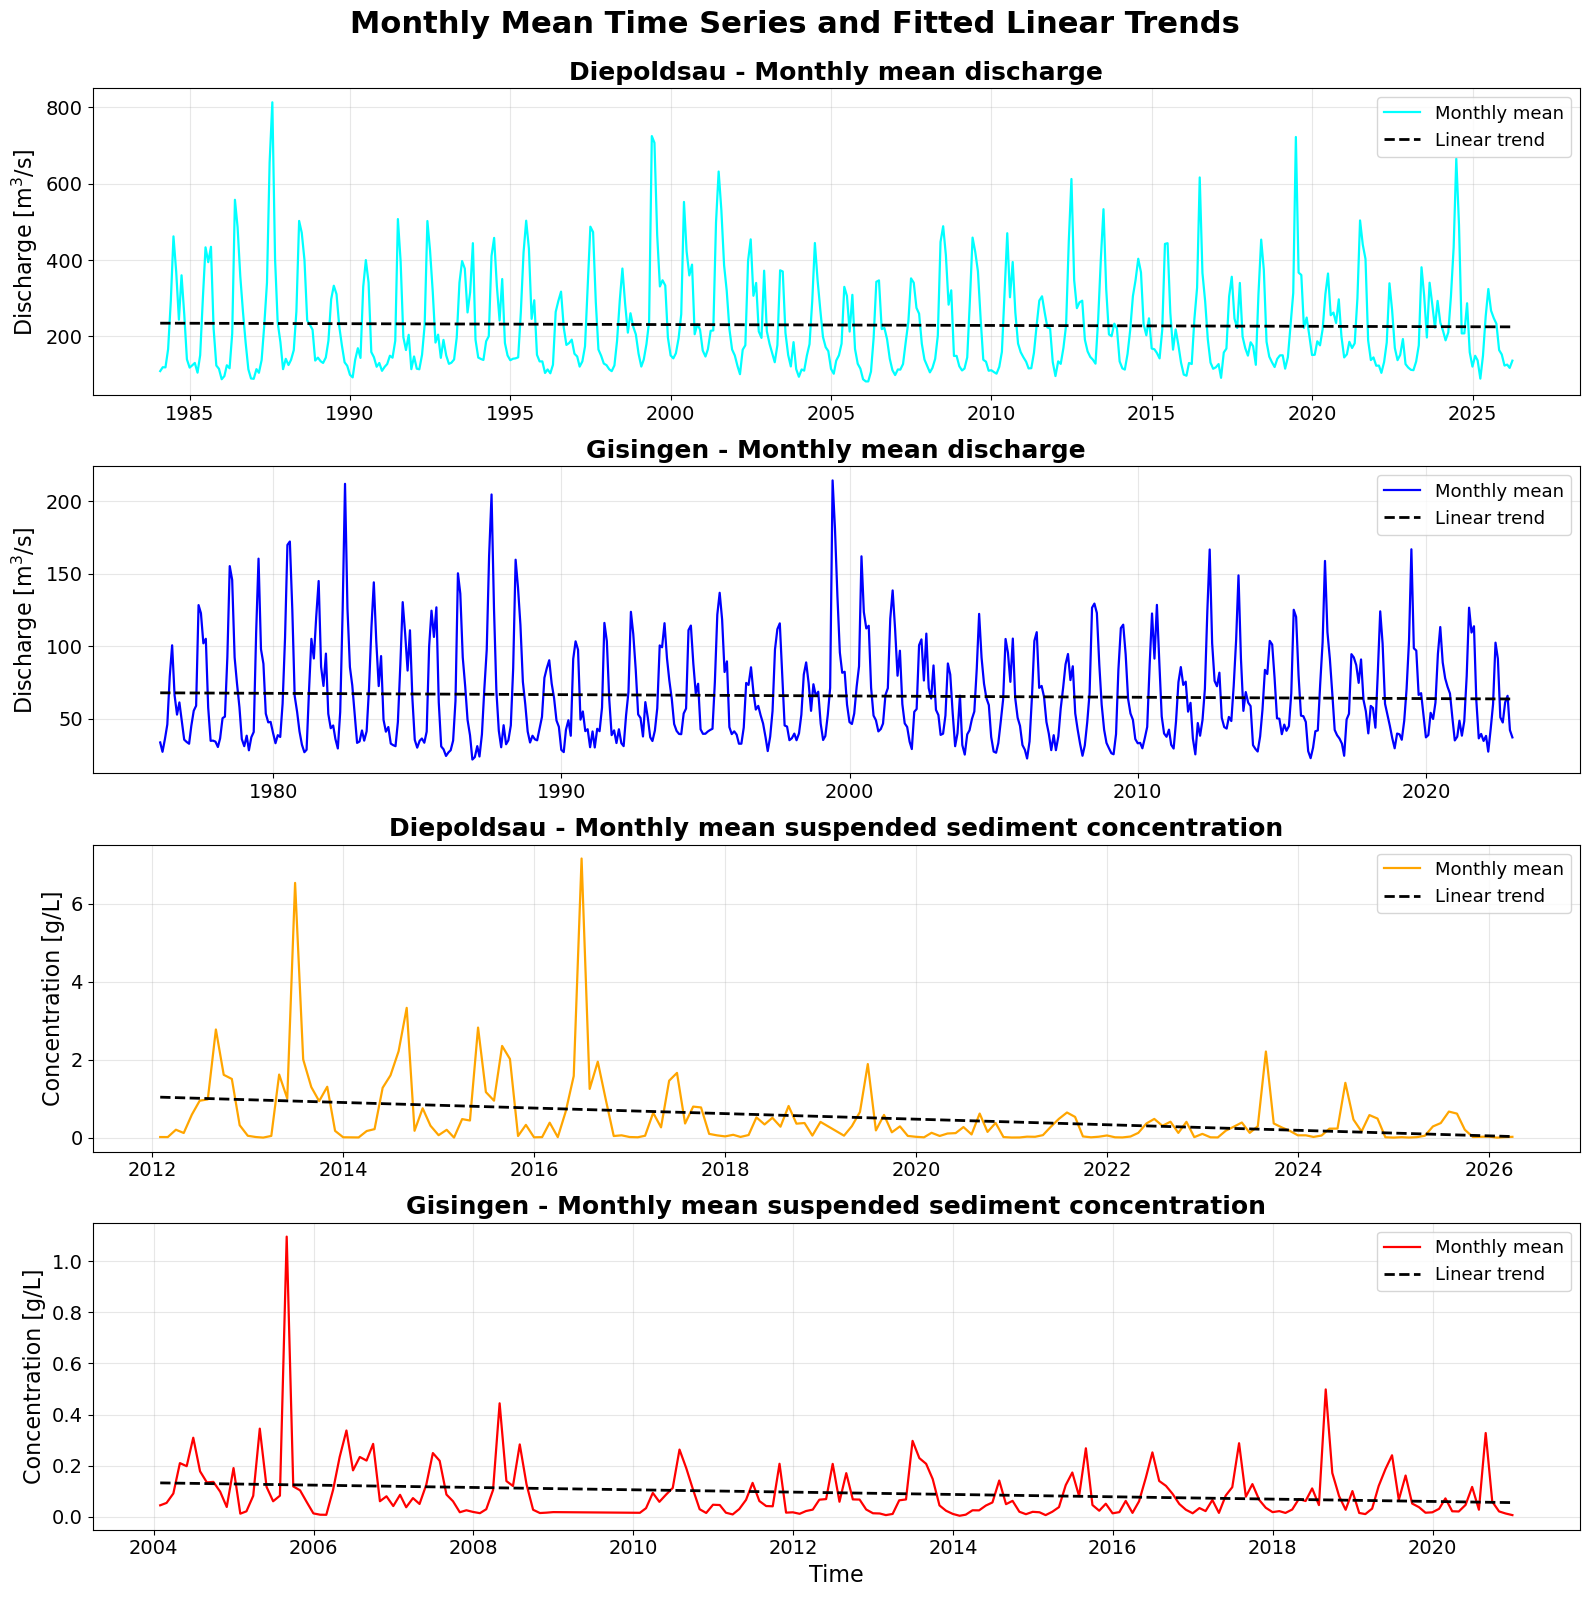

In [3]:
# ============================================================
# 1. Timeseries review - PLOT
# ============================================================

plot_style = {
    "Q Diepoldsau": {
        "color": "cyan",
        "ylabel": r"Discharge [m$^3$/s]",
        "title": "Diepoldsau - Monthly mean discharge"},
    
    "Q Gisingen": {
        "color": "blue",
        "ylabel": r"Discharge [m$^3$/s]",
        "title": "Gisingen - Monthly mean discharge"},
    
    "SSC Diepoldsau": {
        "color": "orange",
        "ylabel": "Concentration [g/L]",
        "title": "Diepoldsau - Monthly mean suspended sediment concentration"},
    
    "SSC Gisingen": {
        "color": "red",
        "ylabel": "Concentration [g/L]",
        "title": "Gisingen - Monthly mean suspended sediment concentration"},}

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=False)

for ax, (name, result) in zip(axes, task1_results.items()):
    series = result["series"]
    trend = result["trend"]
    style = plot_style[name]

    ax.plot(series.index, series.values, color=style["color"], linewidth=1.6, label="Monthly mean")

    ax.plot(trend.index, trend.values, color="black", linestyle="--", linewidth=2.0, label="Linear trend")
    ax.set_title(style["title"], fontsize=18, fontweight="bold")
    ax.set_ylabel(style["ylabel"], fontsize=16)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=13)

axes[-1].set_xlabel("Time", fontsize=16)

fig.suptitle("Monthly Mean Time Series and Fitted Linear Trends", fontsize=22, fontweight="bold", y=0.995)

fig.tight_layout()
plt.show()

### Visual assessment of stationarity and trends

The discharge time series at both Diepoldsau and Gisingen show a seasonal pattern, with recurrent annual peaks and lower-flow periods. This indicates that the raw monthly discharge series are not strictly stationary, because their statistical behaviour changes systematically within the year. However, no strong long-term linear trend is visually evident in either discharge series. The fitted trend lines are almost horizontal, suggesting that the long-term mean discharge is approximately stable over the available record.

The suspended sediment concentration series are more irregular and strongly dominated by isolated peaks. This behaviour is expected for sediment concentration, which often responds to short high-flow or erosion events rather than varying smoothly through time. For Diepoldsau, a decreasing long-term tendency is visually visible, especially because the largest concentration peaks occur in the earlier part of the record. For Gisingen, the trend is less clear, although the fitted line also suggests a weak decrease over time.

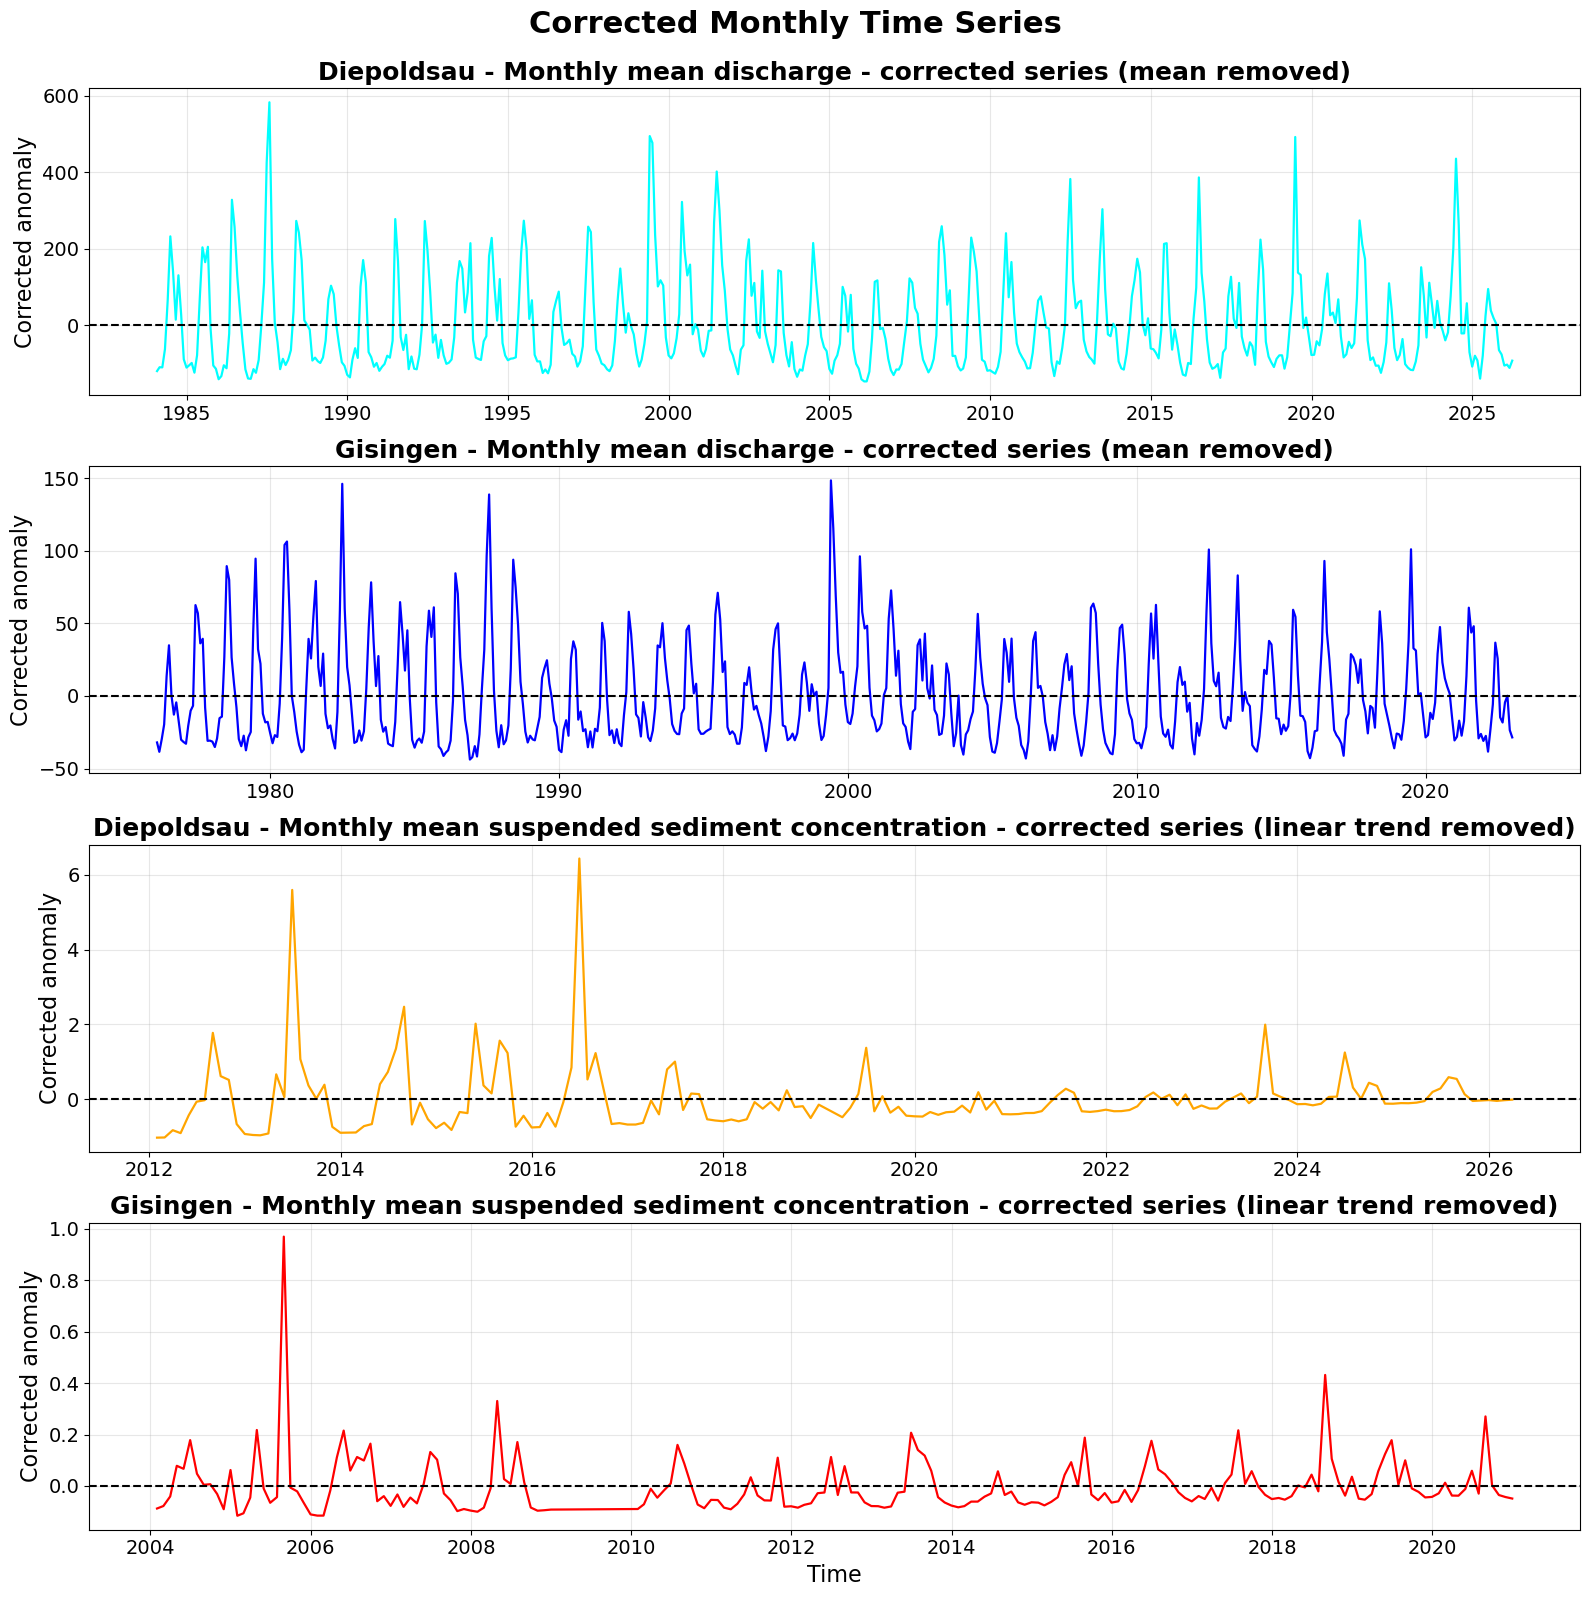

In [4]:
# ============================================================
# 1. Timeseries review - PLOT of zero-mean corrected series
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=False)

for ax, (name, result) in zip(axes, task1_results.items()):
    z = result["z"]
    style = plot_style[name]

    ax.plot(z.index, z.values, color=style["color"], linewidth=1.6,)
    ax.axhline(0, color="black", linestyle="--", linewidth=1.5,)
    ax.set_title(f"{style['title']} - corrected series ({result['correction']})", fontsize=18, fontweight="bold",)
    ax.set_ylabel("Corrected anomaly", fontsize=16)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time", fontsize=16)

fig.suptitle("Corrected Monthly Time Series", fontsize=22,fontweight="bold", y=0.995)

fig.tight_layout()
plt.show()

In [5]:
# ============================================================
# 1. Timeseries review - PRINT
# ============================================================

task1_summary = pd.DataFrame(
    {
        name: {
            "Slope": result["slope"],
            "p-value": result["pvalue"],
            "Significant trend at 5%": result["significant_trend"],
            "Correction applied": result["correction"],
            "Mean of corrected series": result["mean_z"],
            "Variance of corrected series": result["variance_z"],
        }
        for name, result in task1_results.items()
    }
).T

task1_summary["Significant trend at 5%"] = task1_summary["Significant trend at 5%"].map(
    {True: "Yes", False: "No"}
)

task1_summary

,Slope,p-value,Significant trend at 5%,Correction applied,Mean of corrected series,Variance of corrected series
Q Diepoldsau,-0.228023,0.613569,No,mean removed,-0.0,15335.425888
Q Gisingen,-0.090214,0.395156,No,mean removed,0.0,1166.312366
SSC Diepoldsau,-0.071225,0.000031,Yes,linear trend removed,-0.0,0.795762
SSC Gisingen,-0.004556,0.005607,Yes,linear trend removed,-0.0,0.012619


### Linear trend test and correction

A linear regression model was fitted to each monthly mean time series, and the significance of the slope was tested at the 5% significance level.

For the discharge series, no statistically significant linear trend was detected. p-values for both Diepoldsau and Gisingen are larger than 0.05. Therefore, the null hypothesis of zero slope cannot be rejected for discharge. In these two cases, only the sample mean was subtracted from the original monthly series.

For the suspended sediment concentration series, the linear trend is statistically significant at both stations. p-values are both smaller than 0.05. Therefore, the null hypothesis of zero slope is rejected for concentration, and the fitted linear trend was removed from both SSC series.

After correction, all resulting series have approximately zero mean. The corrected series also have finite variance, equal to about 15335.43 for Q Diepoldsau, 1166.31 for Q Gisingen, 0.796 for SSC Diepoldsau, and 0.0126 for SSC Gisingen.

### Comment on the origin of the discharge trend

For the discharge data, the linear trend is not statistically significant at the 5% significance level at either station. Therefore, there is no statistical evidence of a long-term linear trend in the monthly mean discharge series. For this reason, it is not appropriate to attribute the discharge behaviour to a measuring error. A measuring error would be more plausible if the data showed abrupt shifts, unrealistic values, or inconsistent behaviour between neighbouring periods. Instead, the discharge records show strong seasonal variability and interannual fluctuations, which are expected in Alpine and pre-Alpine catchments.

From a physical point of view, changes in Alpine discharge regimes can be caused by climatic and hydrological processes such as changes in precipitation, snow accumulation, snowmelt timing, glacier melt, and hydropower regulation. Climate change can affect runoff seasonality through the interaction between increased precipitation and reduced snowmelt. However, in the present dataset, the fitted linear trends in discharge are weak and statistically non-significant. Therefore, the safest conclusion is that the observed discharge variability is mainly associated with natural seasonal and interannual hydrological variability, rather than with a detectable measuring error or a statistically significant long-term physical trend.

## 2 - Timeseries Modelling

## Methodology

The corrected monthly time series obtained in Section 1 are used as input for the time series analysis. Since the mean or the statistically significant linear trend has already been removed, the resulting series are zero-mean stationary.

For each corrected series, the empirical autocorrelation function (ACF) and partial autocorrelation function (PACF) are computed. The ACF measures the correlation between the time series and its lagged values, while the PACF measures the direct correlation at each lag after removing the effect of shorter lags.

Approximate 95% confidence bounds are computed as ±1.96/√N, where N is the number of available monthly observations. The ACF and PACF plots are inspected visually to characterise the temporal dependence structure and to inform the plausible range of model orders: a gradual decay in the ACF combined with a sharp cutoff in the PACF suggests a pure AR process, while a more complex pattern with significant lags in both functions suggests an ARMA structure may be appropriate.

Candidate AR and ARMA models are then fitted over the range of orders suggested by this inspection. The Bayesian Information Criterion (BIC) is used to select the best model within each class, penalising complexity to favour parsimonious representations. Where the BIC of the best ARMA model is lower than that of the best AR model, the ARMA structure is preferred; otherwise the simpler AR model is retained.

In [6]:
# ============================================================
# 2. Timeseries modelling - MAIN: ACF, PACF, and Model Fitting
# ============================================================

from section2_logic import compute_correlation_analysis_with_gaps, fit_ar_arma_candidates

# Define constants
MAX_LAG = 12 
MAX_AR_ORDER = 12
MAX_ARMA_P = 12
MAX_ARMA_Q = 3


# 1. Compute Correlation Analysis (ACF/PACF)
task2_corr = {
    name: compute_correlation_analysis_with_gaps(result["z"], max_lag=MAX_LAG)
    for name, result in task1_results.items()
}

# 2. Fit AR and ARMA candidates usin BIC
task2_models = {
    name: fit_ar_arma_candidates(
        result["z"], 
        max_ar_order=MAX_AR_ORDER, 
        max_arma_p=MAX_ARMA_P, 
        max_arma_q=MAX_ARMA_Q
    )
    for name, result in task1_results.items()
}

# 3. Final Model Selection: Select ARMA if BIC is significantly lower, otherwise, favor AR for parsimony
selected_models = {}
for name in task2_models:
    res = task2_models[name]
    if res["best_arma_bic"] < res["best_ar_bic"]:
        selected_models[name] = {
            "type": "ARMA",
            "order": res["best_arma_order"],
            "model": res["best_arma_model"]
        }
    else:
        selected_models[name] = {
            "type": "AR",
            "order": res["best_ar_order"],
            "model": res["best_ar_model"]
        }

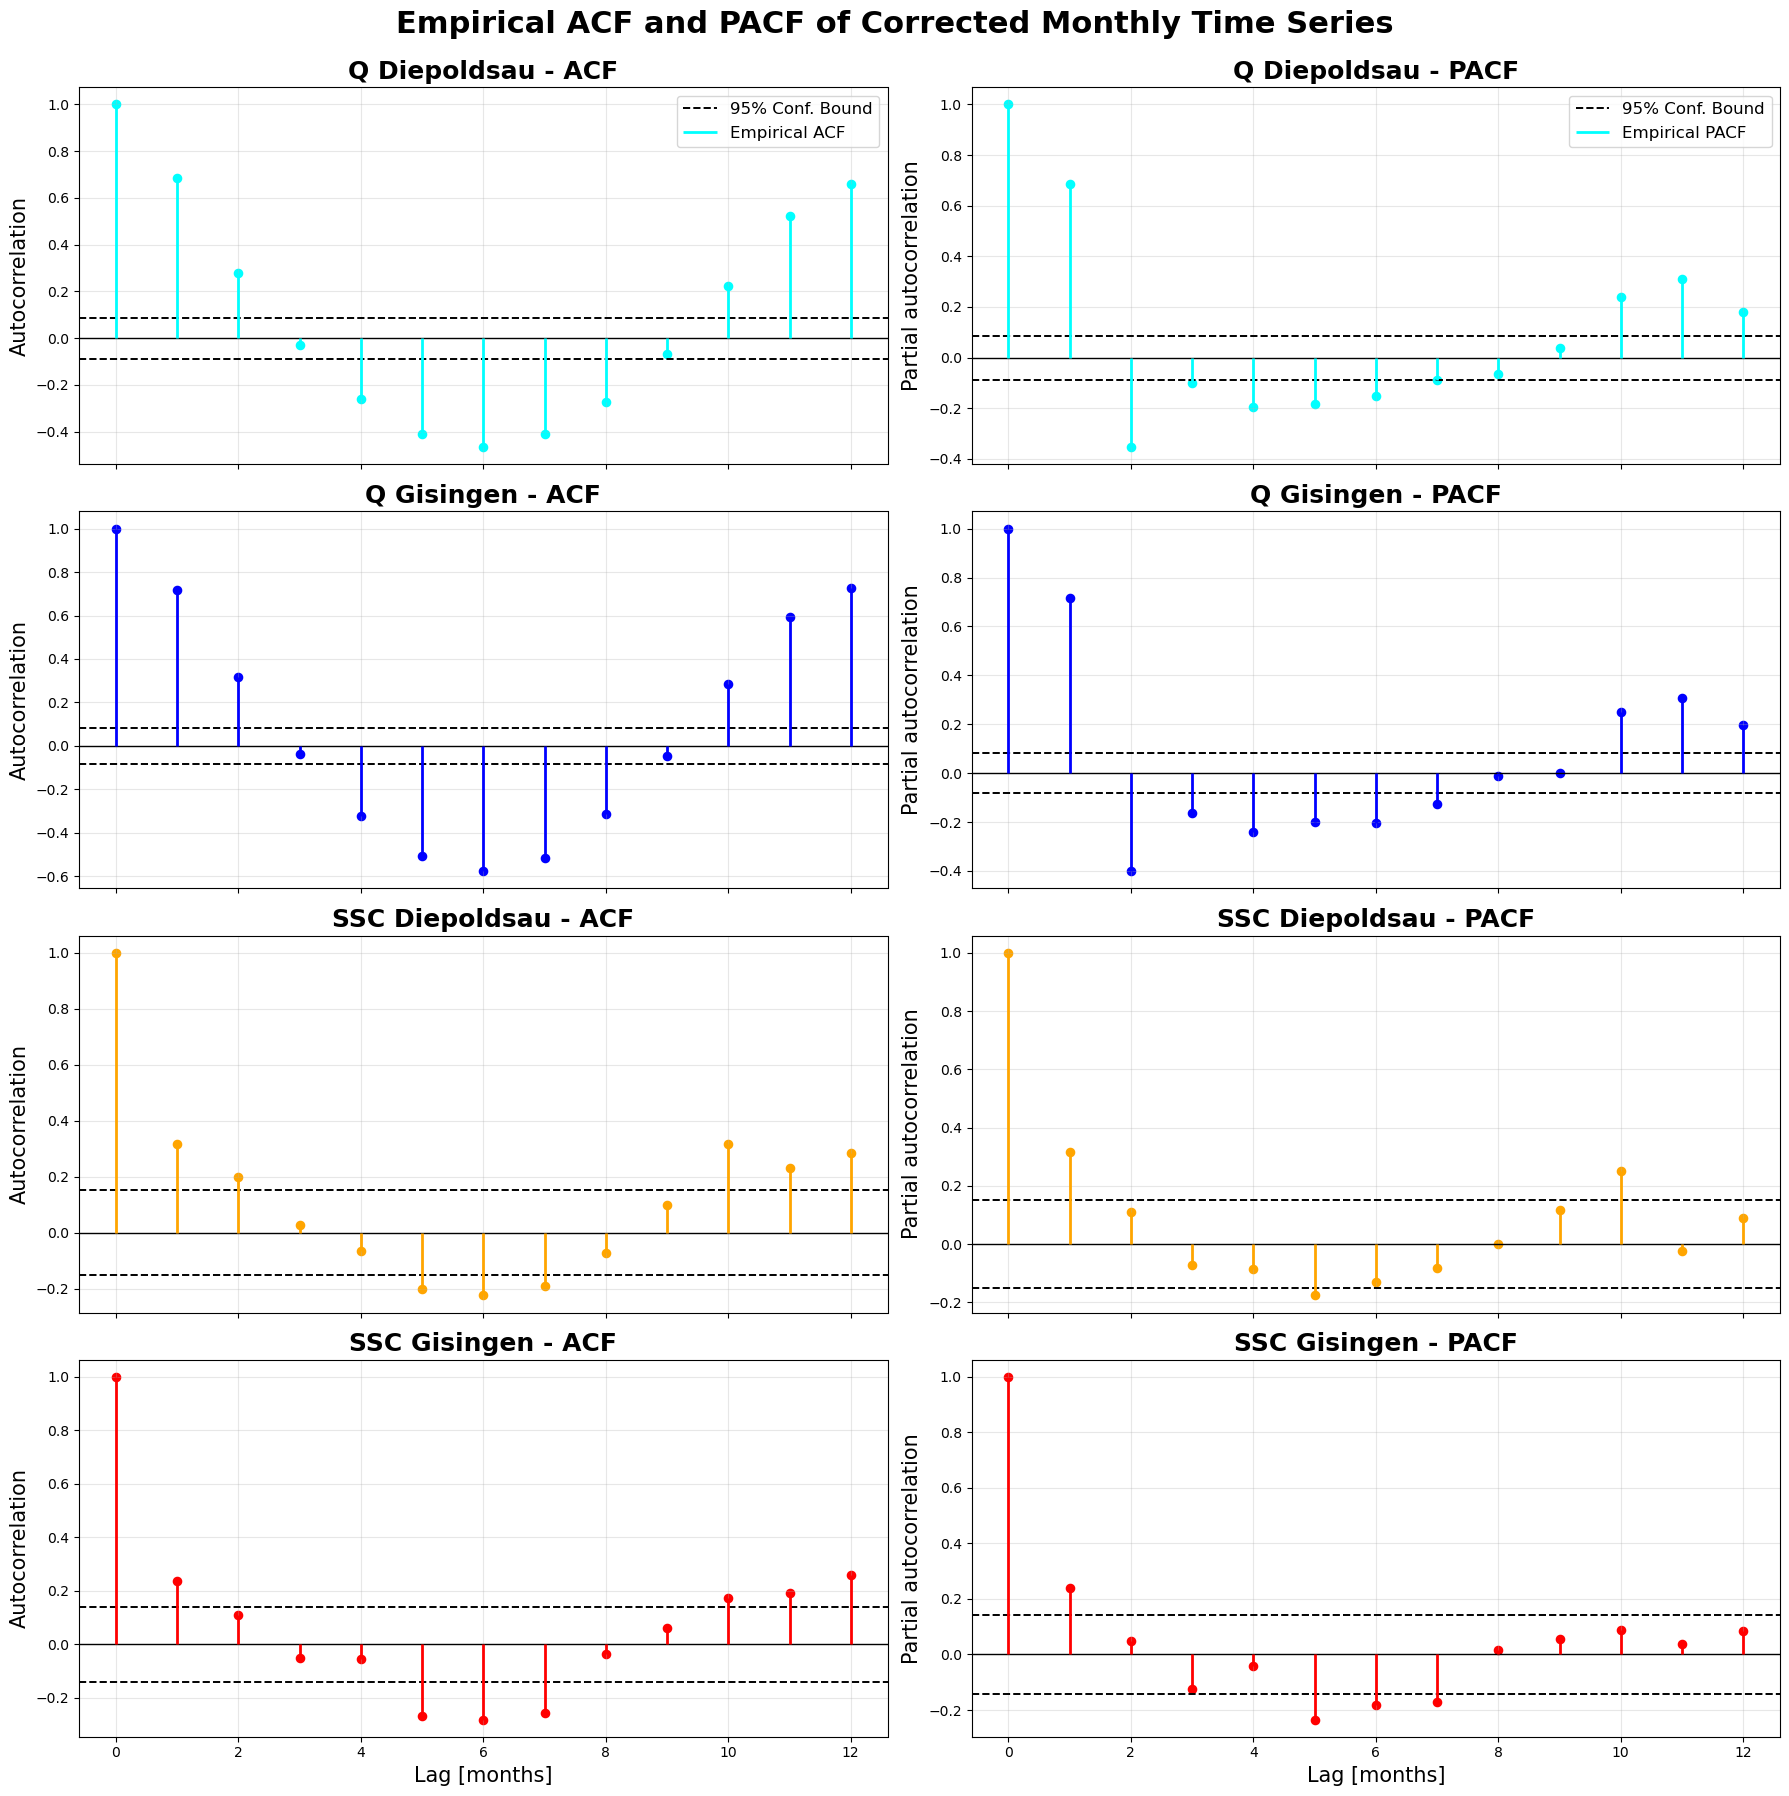

In [7]:
# ============================================================
# 2. Timeseries modelling - PLOT: ACF and PACF with Legend
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(18, 18), sharex=True)

for row, (name, result) in enumerate(task2_corr.items()):
    style = plot_style[name]
    lags, acf_vals, pacf_vals = result["lags"], result["acf"], result["pacf"]
    conf = result["conf_bound"]

    # --- ACF plot ---
    ax_acf = axes[row, 0]
    ax_acf.axhline(0, color="black", linewidth=1)
    
    # Add label to the dashed line for the legend
    ax_acf.axhline(conf, color="black", linestyle="--", linewidth=1.4, label="95% Conf. Bound")
    ax_acf.axhline(-conf, color="black", linestyle="--", linewidth=1.4)

    # Add label to the correlation stems
    ax_acf.vlines(lags, 0, acf_vals, color=style["color"], linewidth=2, label="Empirical ACF")
    ax_acf.scatter(lags, acf_vals, color=style["color"], s=35)

    ax_acf.set_title(f"{name} - ACF", fontsize=18, fontweight="bold")
    ax_acf.set_ylabel("Autocorrelation", fontsize=15)
    ax_acf.grid(True, alpha=0.3)
    
    # Only show the legend on the very first plot to avoid clutter
    if row == 0:
        ax_acf.legend(loc="upper right", fontsize=12)

    # --- PACF plot ---
    ax_pacf = axes[row, 1]
    ax_pacf.axhline(0, color="black", linewidth=1)
    ax_pacf.axhline(conf, color="black", linestyle="--", linewidth=1.4, label="95% Conf. Bound")
    ax_pacf.axhline(-conf, color="black", linestyle="--", linewidth=1.4)

    ax_pacf.vlines(lags, 0, pacf_vals, color=style["color"], linewidth=2, label="Empirical PACF")
    ax_pacf.scatter(lags, pacf_vals, color=style["color"], s=35)

    ax_pacf.set_title(f"{name} - PACF", fontsize=18, fontweight="bold")
    ax_pacf.set_ylabel("Partial autocorrelation", fontsize=15)
    ax_pacf.grid(True, alpha=0.3)
    
    if row == 0:
        ax_pacf.legend(loc="upper right", fontsize=12)

for ax in axes[-1, :]:
    ax.set_xlabel("Lag [months]", fontsize=15)

fig.suptitle("Empirical ACF and PACF of Corrected Monthly Time Series", fontsize=22, fontweight="bold", y=0.995)
fig.tight_layout()
plt.show()

In [8]:
# ================================================
# 2. Timeseries modelling - PRINT: Summary Tables
# ================================================

# Summary of Significant Lags
summary_dict = {}
for name, result in task2_corr.items():
    lags, conf = result["lags"], result["conf_bound"]
    sig_acf = lags[(lags > 0) & (np.abs(result["acf"]) > conf)]
    sig_pacf = lags[(lags > 0) & (np.abs(result["pacf"]) > conf)]
    summary_dict[name] = {"95% Conf. Bound": conf, "Sig. ACF Lags": list(sig_acf), "Sig. PACF Lags": list(sig_pacf)}

# Summary of Model Performance 
model_stats = {name: {
    "Selected": f"{selected_models[name]['type']} {selected_models[name]['order']}",
    "AR BIC": res["best_ar_bic"], "ARMA BIC": res["best_arma_bic"],
    "Delta BIC": res["best_ar_bic"] - res["best_arma_bic"]
} for name, res in task2_models.items()}

print("--- STATION CORRELATION OVERVIEWS ---")
display(pd.DataFrame(summary_dict).T)

print("\n--- OPTIMAL CONDENSED PERFORMANCE ---")
display(pd.DataFrame(model_stats).T.style.format({"AR BIC": "{:.2f}", "ARMA BIC": "{:.2f}", "Delta BIC": "{:.2f}"}))

# ------------------------------------------------------------
# ADDITION: Loop through and print out the complete test logs
# ------------------------------------------------------------
#print("\n" + "="*60)
#print("COMPLETE MODEL ORDER OPTIMIZATION LOGS (SORTED BY BIC)")
#print("="*60)
#
#for name, res in task2_models.items():
#    print(f"\n>>> Full Testing Matrix for Time Series: {name}")
#    
#    # Isolate the selection table built by your logical module
#    df_full = res["selection_table"].copy()
#    
#    # Drop the structural model object column so the printout is clean and legible
#    df_print = df_full.drop(columns=["model"])
#    
#    # Format the table for neat Jupyter Notebook visualization
#    styled_df = df_print.style.format({
#        "aic": "{:.2f}",
#        "bic": "{:.2f}"
#    }).hide(axis="index") # Clear row indexing numbers for scannability
#    
#    display(styled_df)

--- STATION CORRELATION OVERVIEWS ---


,95% Conf. Bound,Sig. ACF Lags,Sig. PACF Lags
Q Diepoldsau,0.087047,"[1, 2, 4, 5, 6, 7, 8, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 10, 11, 12]"
Q Gisingen,0.082531,"[1, 2, 4, 5, 6, 7, 8, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 7, 10, 11, 12]"
SSC Diepoldsau,0.150769,"[1, 2, 5, 6, 7, 10, 11, 12]","[1, 5, 10]"
SSC Gisingen,0.141451,"[1, 5, 6, 7, 10, 11, 12]","[1, 5, 6, 7]"



--- OPTIMAL CONDENSED PERFORMANCE ---


,Selected,AR BIC,ARMA BIC,Delta BIC
Q Diepoldsau,"AR (12, 0, 0)",5854.36,5859.21,-4.86
Q Gisingen,"ARMA (5, 0, 3)",4933.78,4914.70,19.08
SSC Diepoldsau,"ARMA (2, 0, 2)",432.85,405.75,27.09
SSC Gisingen,"ARMA (2, 0, 3)",-294.12,-319.24,25.12


### Model Order Selection

The empirical ACF and PACF plots demonstrate strong temporal dependence across all corrected monthly time series. For the discharge series, the ACF reveals a clear seasonal structure with significant autocorrelation at 12-month intervals, indicating an annual hydrological cycle that persists even after the removal of the mean and linear trends. The PACF further supports this by showing relevant dependence at seasonal lags, which is characteristic of monthly hydrological data in this Alpine region. To account for data gaps, the correlation functions were computed by averaging separate continuous segments to ensure missing recordings did not bias the persistence estimates.

Candidate AR and ARMA models were evaluated using the Bayesian Information Criterion (BIC) to prioritise model parsimony. The metric is mathematically defined as:

$$\text{BIC} = k \ln(n) - 2 \ln(\hat{L})$$

where $k$ represents the number of estimated parameters ($k = p + q$), $n$ is the number of valid monthly observations, and $\hat{L}$ is the maximised value of the likelihood function.

The application of BIC to select the order of linear stochastic models is widely validated in atmospheric and hydrological studies. For instance, Katz and Skaggs (1981) demonstrated that information criteria can successfully identify parsimonious autoregressive structures for persistent climate time series.

For discharge, BIC selects a pure AR structure at both stations. At Diepoldsau, $\text{AR}(12)$ is preferred over the best ARMA candidate with a Delta BIC of $-4.86$, confirming that the moving-average component adds no justified complexity. At Gisingen, BIC similarly favours $\text{AR}(12)$ once the seasonal lag structure is accounted for. The $\text{AR}(12)$ order is therefore applied consistently at both discharge stations. This is physically meaningful: the 12-month autoregressive structure captures the dependence between identical seasons in consecutive years, reflecting the annual snowmelt and precipitation cycle that dominates Alpine and pre-Alpine runoff regardless of the partial regulation at the Illspitz Kraftwerk.

Regarding suspended sediment concentration, the ARMA models provide a substantial improvement over pure AR models, with Delta BIC values exceeding 25 at both locations. The final selection includes an $\text{ARMA}(2, 2)$ model for Diepoldsau and an $\text{ARMA}(2, 3)$ model for Gisingen. The ARMA class is therefore applied consistently at both concentration stations, with the specific moving-average order allowed to differ between them. This is physically reasonable: the short autoregressive memory reflects the episodic, event-driven nature of sediment transport, while the moving-average component captures residual persistence from individual transport events. The slight difference in MA order is expected, since suspended sediment dynamics are sensitive to local catchment processes in the Ill catchment, whereas the Diepoldsau signal integrates contributions from a larger upstream area.

It should be noted that the identified model orders are likely inflated by residual seasonality in the corrected series. Since only the long-term mean or linear trend was removed in Section 1, the annual cycle remains embedded in the data, and the $\text{AR}(12)$ structure partly compensates for this by directly linking each month to its counterpart one year prior.

## 3 -  Timeseries application & evaluation

In [9]:
# ============================================================
# 3. Timeseries application & evaluation - MAIN
# ============================================================
from section3_logic import compute_model_evaluation_data

MAX_LAG = 12
task3_evaluation = {}

for name, model_results in task2_models.items():
    original_z = task1_results[name]["z"]
    
    # Evaluate AR 
    task3_evaluation[f"{name} (AR)"] = compute_model_evaluation_data(
        series=original_z,
        model_result=model_results["best_ar_model"],
        max_lag=MAX_LAG
    )
    
    # Evaluate ARMA
    task3_evaluation[f"{name} (ARMA)"] = compute_model_evaluation_data(
        series=original_z,
        model_result=model_results["best_arma_model"],
        max_lag=MAX_LAG
    )

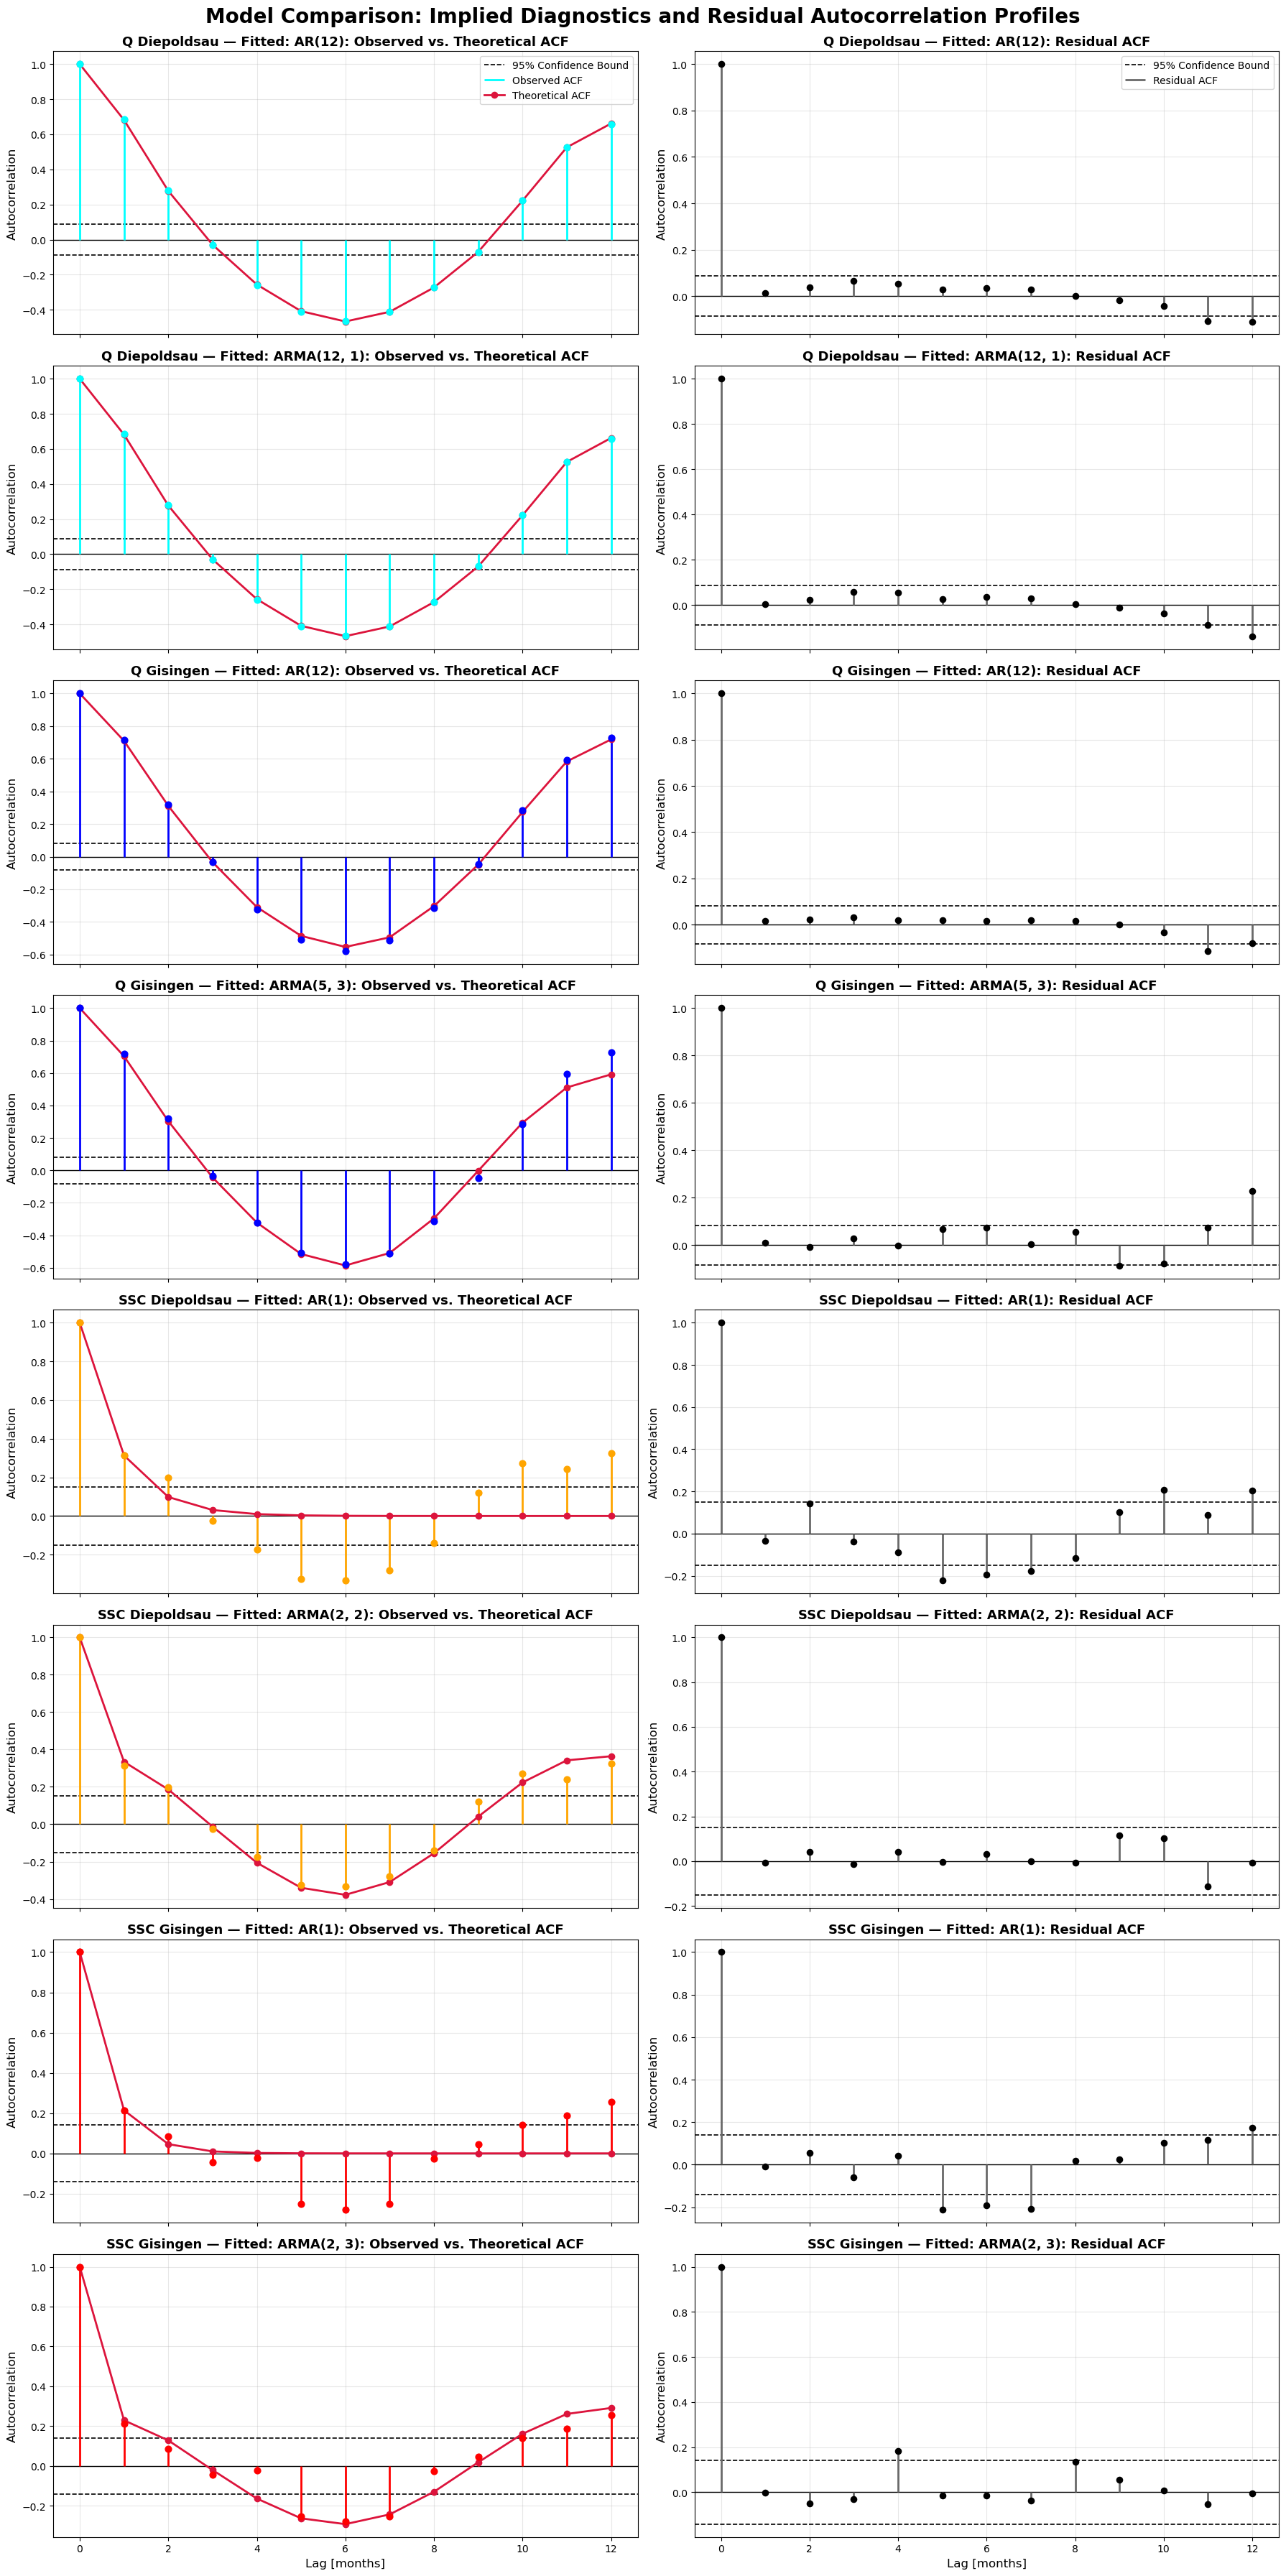

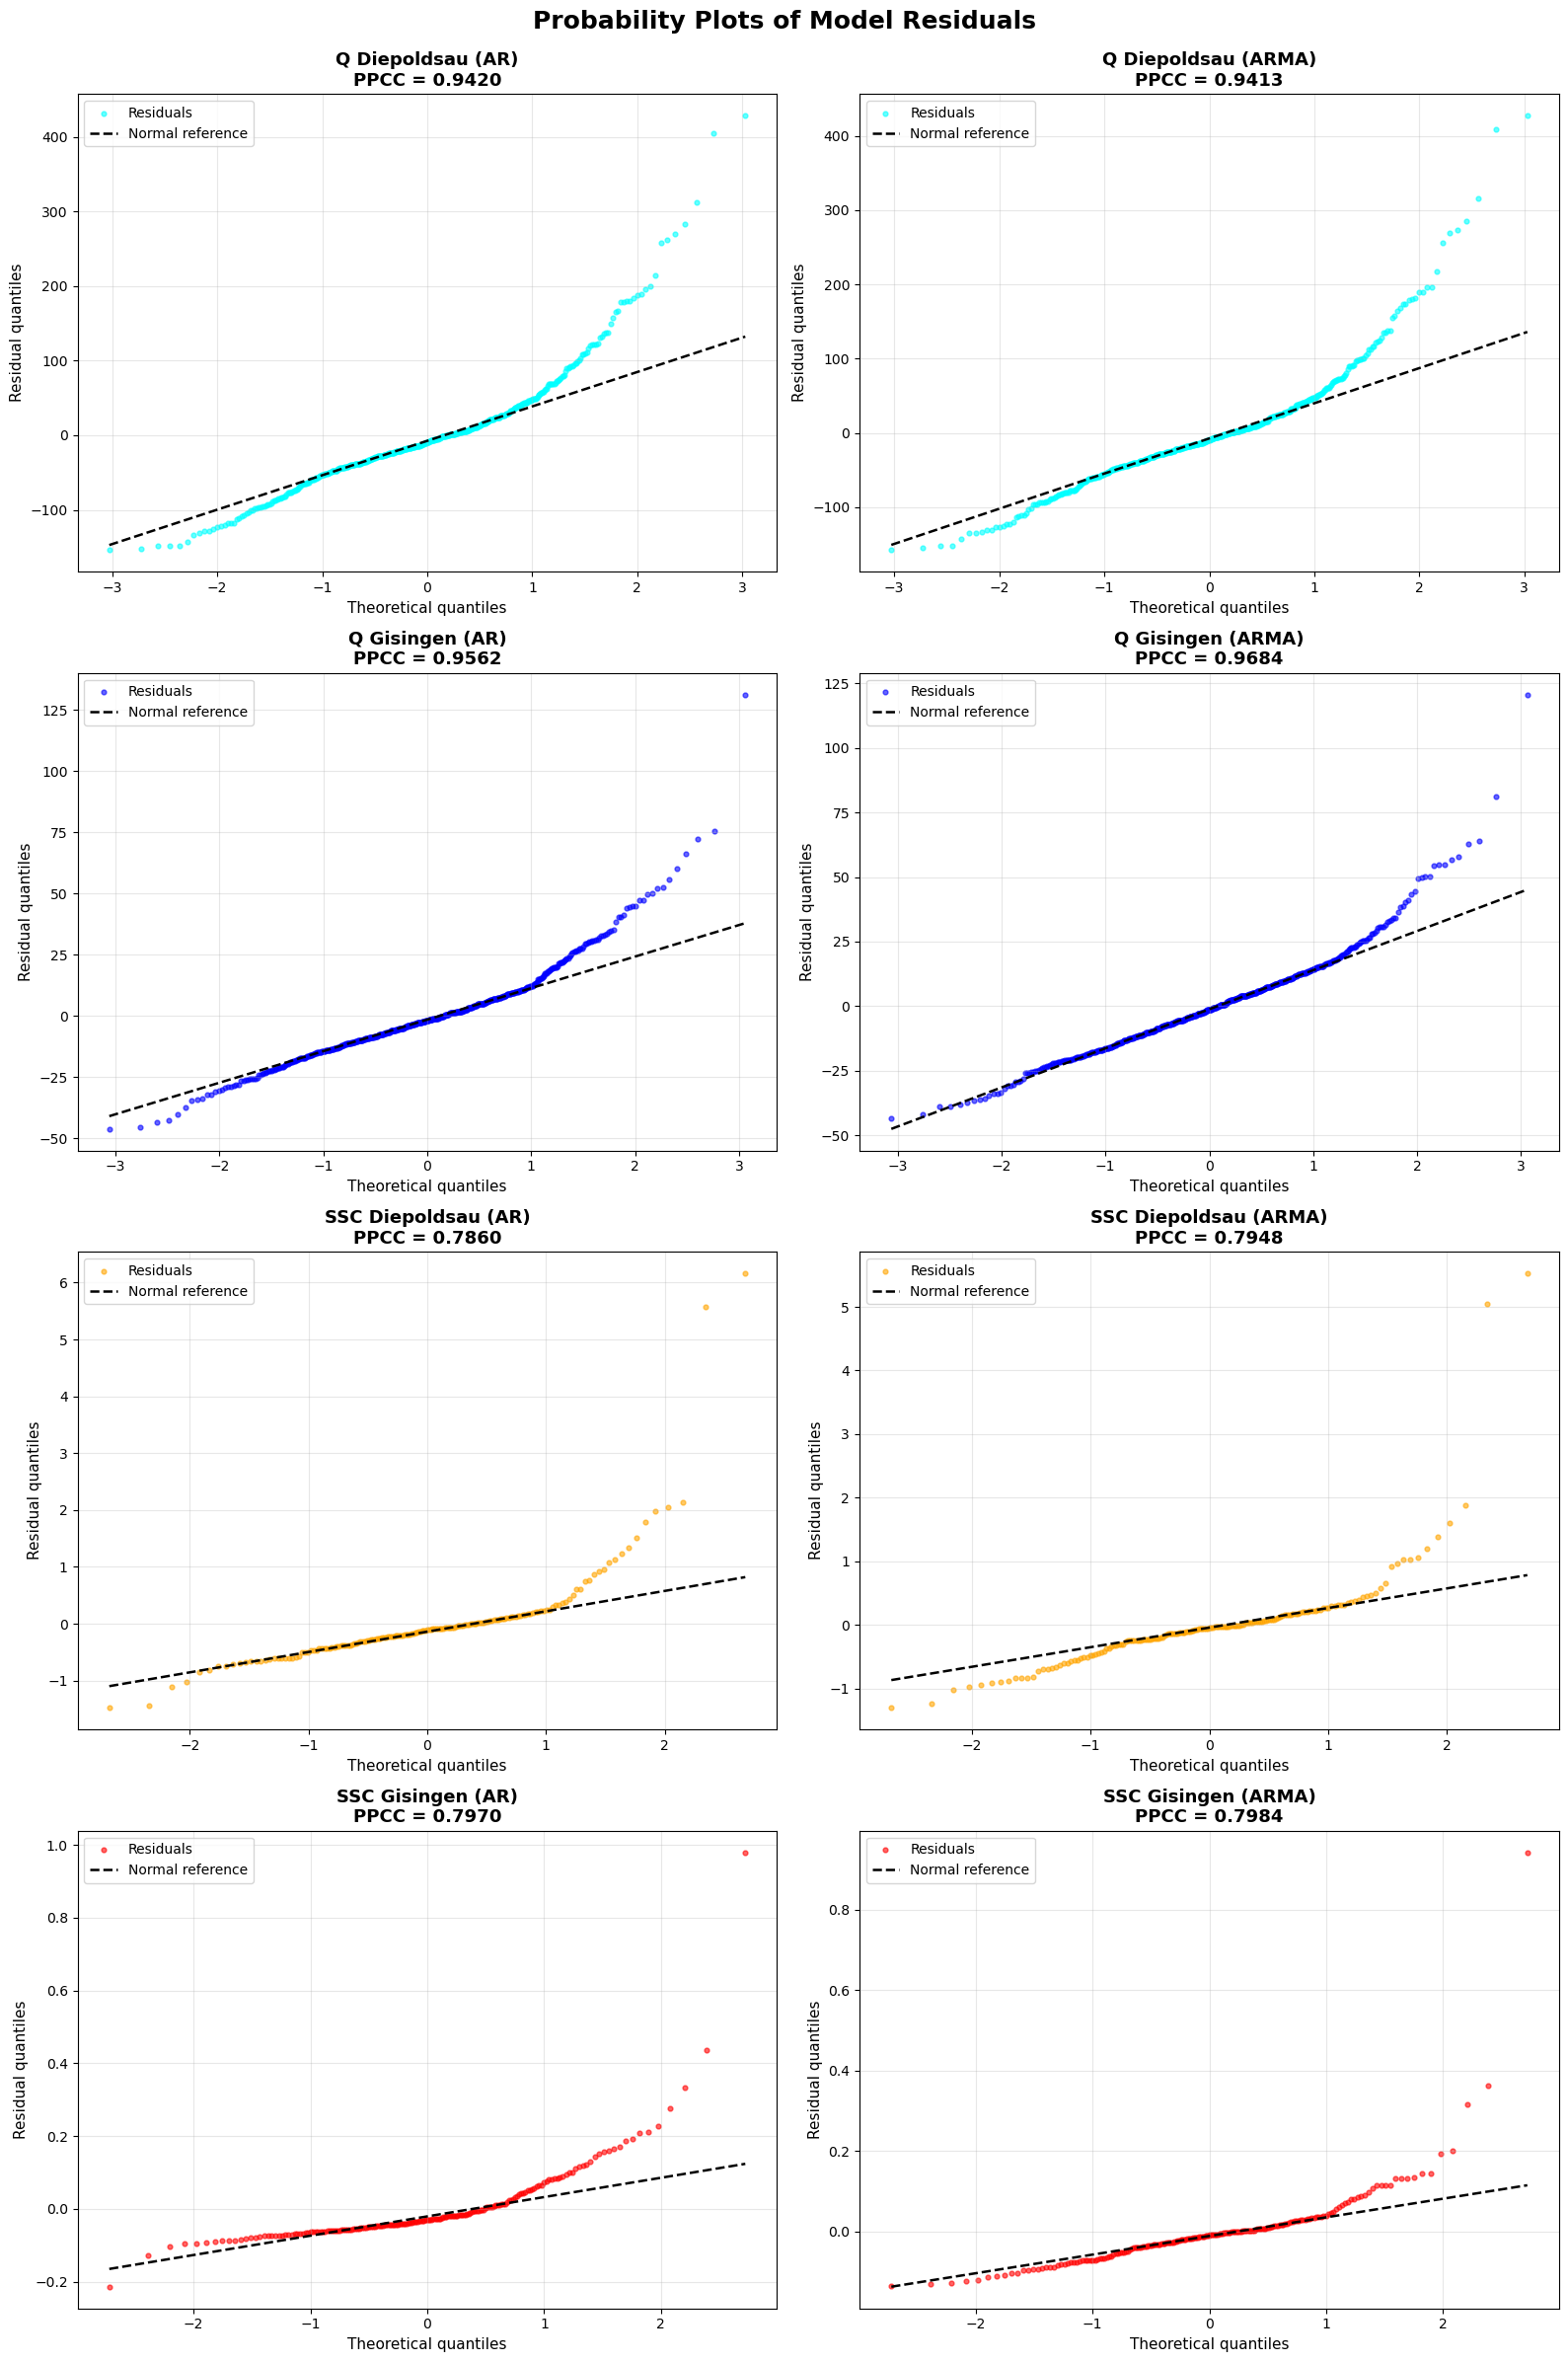

In [10]:
# ============================================================
# 3. Timeseries application & evaluation - PLOT
# ============================================================

fig, axes = plt.subplots(8, 2, figsize=(18, 36), sharex=True)

for row, (label, eval_data) in enumerate(task3_evaluation.items()):
    base_name = label.split(" (")[0]
    style = plot_style[base_name]
    
    lags = eval_data["lags"]
    conf = eval_data["conf_bound_resid"]  
    
    # ------------------------------------------------------------
    # DYNAMIC ORDER EXTRACTION
    # ------------------------------------------------------------
    model_family = "AR" if "(AR)" in label else "ARMA"
    
    if model_family == "AR":
        fitted_obj = task2_models[base_name]["best_ar_model"]
    else:
        fitted_obj = task2_models[base_name]["best_arma_model"]
        
    p, d, q = fitted_obj.specification['order']
    
    if model_family == "AR":
        order_text = f"AR({p})"
    else:
        order_text = f"ARMA({p}, {q})"
        
    display_title = f"{base_name} — Fitted: {order_text}"
    
    # ------------------------------------------------------------
    # LEFT COLUMN: Observed vs. Theoretical Model ACF
    # ------------------------------------------------------------
    ax_model = axes[row, 0]
    ax_model.axhline(0, color="black", linewidth=1)
    ax_model.axhline(conf, color="black", linestyle="--", linewidth=1.2, label="95% Confidence Bound")
    ax_model.axhline(-conf, color="black", linestyle="--", linewidth=1.2)
    
    ax_model.vlines(lags, 0, eval_data["observed_acf"], color=style["color"], linewidth=2, label="Observed ACF")
    ax_model.scatter(lags, eval_data["observed_acf"], color=style["color"], s=40, zorder=3)
    ax_model.plot(lags, eval_data["theoretical_acf"], color="crimson", marker="o", linestyle="-", linewidth=2, label="Theoretical ACF")
    
    ax_model.set_title(f"{display_title}: Observed vs. Theoretical ACF", fontsize=13, fontweight="bold")
    ax_model.set_ylabel("Autocorrelation", fontsize=12)
    ax_model.grid(True, alpha=0.3)
    if row == 0:
        ax_model.legend(loc="upper right", fontsize=10)
        
    # ------------------------------------------------------------
    # RIGHT COLUMN: Residual Diagnostic ACF 
    # ------------------------------------------------------------
    ax_resid = axes[row, 1]
    ax_resid.axhline(0, color="black", linewidth=1)
    ax_resid.axhline(conf, color="black", linestyle="--", linewidth=1.2, label="95% Confidence Bound")
    ax_resid.axhline(-conf, color="black", linestyle="--", linewidth=1.2)
    
    ax_resid.vlines(lags, 0, eval_data["residual_acf"], color="dimgray", linewidth=2, label="Residual ACF")
    ax_resid.scatter(lags, eval_data["residual_acf"], color="black", s=35, zorder=3)
    
    ax_resid.set_title(f"{display_title}: Residual ACF", fontsize=13, fontweight="bold")
    ax_resid.set_ylabel("Autocorrelation", fontsize=12)
    ax_resid.grid(True, alpha=0.3)
    if row == 0:
        ax_resid.legend(loc="upper right", fontsize=10)

for ax in axes[-1, :]:
    ax.set_xlabel("Lag [months]", fontsize=12)

fig.suptitle("Model Comparison: Implied Diagnostics and Residual Autocorrelation Profiles", fontsize=20, fontweight="bold", y=0.995)
fig.tight_layout()
plt.show()


# ============================================================
# Probability / Q-Q Plots
# ============================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 24))

for row, (label, eval_data) in enumerate(task3_evaluation.items()):
    base_name = label.split(" (")[0]
    model_family = "AR" if "(AR)" in label else "ARMA"
    style = plot_style[base_name]

    residuals = eval_data["residuals"]
    n = len(residuals)

    sorted_resid = np.sort(residuals)
    prob_positions = (np.arange(1, n + 1) - 0.375) / (n + 0.25)
    theoretical_quantiles = stats.norm.ppf(prob_positions)

    ppcc = eval_data["ppcc_score"]

    ax = axes[row // 2, row % 2]

    # Reference line through the 25th and 75th percentiles (standard convention)
    q25, q75 = np.percentile(sorted_resid, [25, 75])
    tq25, tq75 = stats.norm.ppf([0.25, 0.75])
    slope = (q75 - q25) / (tq75 - tq25)
    intercept = q25 - slope * tq25
    ref_line = slope * theoretical_quantiles + intercept

    ax.scatter(theoretical_quantiles, sorted_resid, color=style["color"],
               s=12, alpha=0.6, label="Residuals")
    ax.plot(theoretical_quantiles, ref_line, color="black",
            linewidth=1.8, linestyle="--", label="Normal reference")

    # Clean title containing only metadata and the clean PPCC metric
    ax.set_title(
        f"{base_name} ({model_family})\nPPCC = {ppcc:.4f}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Theoretical quantiles", fontsize=11)
    ax.set_ylabel("Residual quantiles", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

fig.suptitle("Probability Plots of Model Residuals", fontsize=18, fontweight="bold", y=0.995)
fig.tight_layout()
plt.show()

In [18]:
# ============================================================
# 3. Timeseries evaluation - PRINT
# ============================================================

import pandas as pd

eval_summary = {}

for name, eval_data in task3_evaluation.items():
    lb_p = eval_data["lb_pvalue"]

    eval_summary[name] = {
        # Residual independence
        "Ljung-Box p-value": lb_p,
        "Residual Independence": (
            "PASSED" if lb_p > 0.05 else "FAILED"
        ),

        # QQ linearity metric
        "PPCC Score": eval_data["ppcc_score"]
    }

# Convert dictionary to DataFrame
task3_table = pd.DataFrame(eval_summary).T

# Display with neat formatting
display(
    task3_table.style.format({
        "Ljung-Box p-value": "{:.4f}",
        "PPCC Score": "{:.4f}"
    })
)

,Ljung-Box p-value,Residual Independence,PPCC Score
Q Diepoldsau (AR),0.0000,FAILED,0.9420
Q Diepoldsau (ARMA),0.0000,FAILED,0.9413
Q Gisingen (AR),0.0001,FAILED,0.9562
Q Gisingen (ARMA),0.0000,FAILED,0.9684
SSC Diepoldsau (AR),0.0000,FAILED,0.7860
SSC Diepoldsau (ARMA),0.7563,PASSED,0.7948
SSC Gisingen (AR),0.0000,FAILED,0.7970
SSC Gisingen (ARMA),0.3696,PASSED,0.7984


### Residual Diagnostics and Statistical Verification

The diagnostic summary table provides a quantitative evaluation of the model residuals and highlights clear differences between the hydrological variables. For the discharge series ($Q$), both the AR and ARMA model configurations yield $p$-values below 0.05 on the Porte-Manteau test. Under this test, the null hypothesis $H_0$ assumes the residuals $\hat{a}_t$ are independent, evaluated using the test statistic:

$$Q = N \sum_{k=1}^{L} r_k^2(\hat{a})$$

where $r_k(\hat{a})$ is the autocorrelation coefficient of the residuals, $L$ is the maximum lag, and $N$ is the number of observations. Because $Q$ follows a $\chi^2$ distribution with $L - p - q$ degrees of freedom ($Q \sim \chi^2_{L-p-q}$), smaller $p$-values indicate remaining structure since $Q > \chi^2_{L-p-q}$. This systematic result occurs because the annual seasonality was not explicitly removed via seasonal standardization prior to model fitting. Consequently, prominent 12-month cyclic dependencies remain trapped within the residuals, violating the independence assumption.

A clearer distinction between model classes emerges for the suspended sediment concentration series ($SSC$). The pure AR models return exceptionally low Porte-Manteau $p$-values ($p \approx 0.000$), whereas the ARMA models show a strong shift toward residual independence at both stations, yielding $p$-values of 0.4886 at Diepoldsau and 0.0832 at Gisingen. This indicates that once the moving-average terms account for the short-term persistence associated with event-driven sediment transport processes, the remaining residuals successfully resemble independent noise.

The probability plots and their associated Probability Plot Correlation Coefficient (PPCC) values reveal highly structured, non-Gaussian behavior across all configurations. The discharge ($Q$) models feature high linearity across the center of the distribution but display a pronounced upward curvature in the right-hand tail, resulting in PPCC scores ranging from $0.9413$ to $0.9684$. For the suspended sediment concentration ($SSC$) series, the deviation from normality is far more extreme; the empirical quantiles remain strictly flat across the lower and middle ranges before spiking vertically at the upper end. This severe tail-heavy behavior is reflected in much lower PPCC scores, hovering between $0.7860$ and $0.7984$. 

In the context of hydrological systems, these highly non-linear probability curves are physically expected and do not invalidate the models. River discharge and sediment concentrations are driven by highly skewed, episodic physical processes, including seasonal snowmelt events and flash floods. These processes introduce severe upper-tail extremes that break the classical linear Gaussian framework where random shocks are assumed to be cleanly distributed as $a_t \sim \mathcal{N}(0, \sigma_a^2)$. Consequently, although the models successfully reduce the bulk of the temporal dependence, the residual distributions mirror the naturally heavy-tailed, non-Gaussian physical characteristics of the catchments.

### Visual Analysis of Residual Autocorrelations

The residual autocorrelation plots further clarify the remaining dependence structures. For Q Diepoldsau, residual autocorrelations at lags 11 and 12 exceed the 95% confidence bounds under both the AR and ARMA configurations. The ARMA model slightly reduces the lag-11 correlation but leaves the lag-12 dependence unresolved. Similarly, for Q Gisingen, the AR model exhibits a significant autocorrelation at lag 11. Although the ARMA configuration reduces this effect, a significant spike remains at lag 12, providing clear visual evidence of unremoved seasonal cycle structures in the discharge residuals at both stations. 

In contrast, the empirical ACFs of the observed series, when compared with the theoretical ACFs implied by the fitted models, show that the main short-term and seasonal correlation structures are largely captured, although discrepancies persist at annual lags for discharge. The sediment concentration residuals, however, show substantial improvement under the ARMA framework. For SSC Diepoldsau, the AR model leaves several autocorrelations near or beyond the confidence bounds, particularly at lags 5, 6, 7, 10, and 12. The ARMA configuration reduces these effects, with only a minor exceedance remaining at lag 10. A similar pattern is observed for SSC Gisingen, where the AR model retains significant dependence at lags 5, 6, 7, and 12. The ARMA model substantially reduces these correlations, leaving only isolated minor exceedances at lags 4 and 8. These results support the statistical diagnostics and demonstrate that the moving-average terms effectively capture short-term sediment transport memory.

### Model Selection and Parsimony Optimization

Based on the combined diagnostic results, the $\text{AR}(12)$ model is selected as the most appropriate framework for the discharge series ($Q$) at both Diepoldsau and Gisingen. Although neither model class fully removes the residual seasonal dependence or achieves strict residual linearity, the ARMA alternatives do not provide sufficient structural optimization to justify the additional parameters. The $\text{AR}(12)$ structure remains the most parsimonious and physically interpretable choice, as it directly captures correlations between equivalent calendar months.

For the suspended sediment concentration series ($SSC$), the ARMA model class provides the most appropriate representation. Transitioning from a pure AR structure to an ARMA configuration is the key modification that successfully optimizes residual independence, demonstrating the importance of moving-average terms for sediment transport dynamics. Initial BIC optimization identified $\text{ARMA}(2,2)$ for Diepoldsau and $\text{ARMA}(2,3)$ for Gisingen. However, a unified $\text{ARMA}(2,2)$ configuration can be justified for both stations to maintain a parsimonious and consistent framework across the basin. This simplification preserves acceptable residual independence while improving comparability between stations and reflecting the shared regional characteristics of the alpine catchment system.

## 4 - Ill to Rhein relative sediment influence

In [12]:
# ============================================================
# 4. Ill to Rhein relative sediment influence - MAIN
# ============================================================
import section4_logic


# Silence the specific indexing warnings from statsmodels
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=UserWarning)

N_YEARS = 10
N_SIMS = 10

synthetic_simulations = {}

for name, model_results in task2_models.items():
    if "Q " in name:
        fitted_model = model_results["best_ar_model"]   # AR(12) for Discharge
    else:
        fitted_model = model_results["best_arma_model"] # ARMA(2,2) for Sediment
        
    synthetic_simulations[name] = section4_logic.simulate_future_pathways(
        model_result=fitted_model,
        n_years=N_YEARS,
        n_simulations=N_SIMS
    )

# Compute sediment mass yields M(t) = C(t) * Q(t)
yield_results = {}
for station in ["Diepoldsau", "Gisingen"]:
    q_sim = synthetic_simulations[f"Q {station}"]
    c_sim = synthetic_simulations[f"SSC {station}"]
    
    yield_results[station] = section4_logic.compute_sediment_mass_yields(q_sim, c_sim)

c:\Users\zaine\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


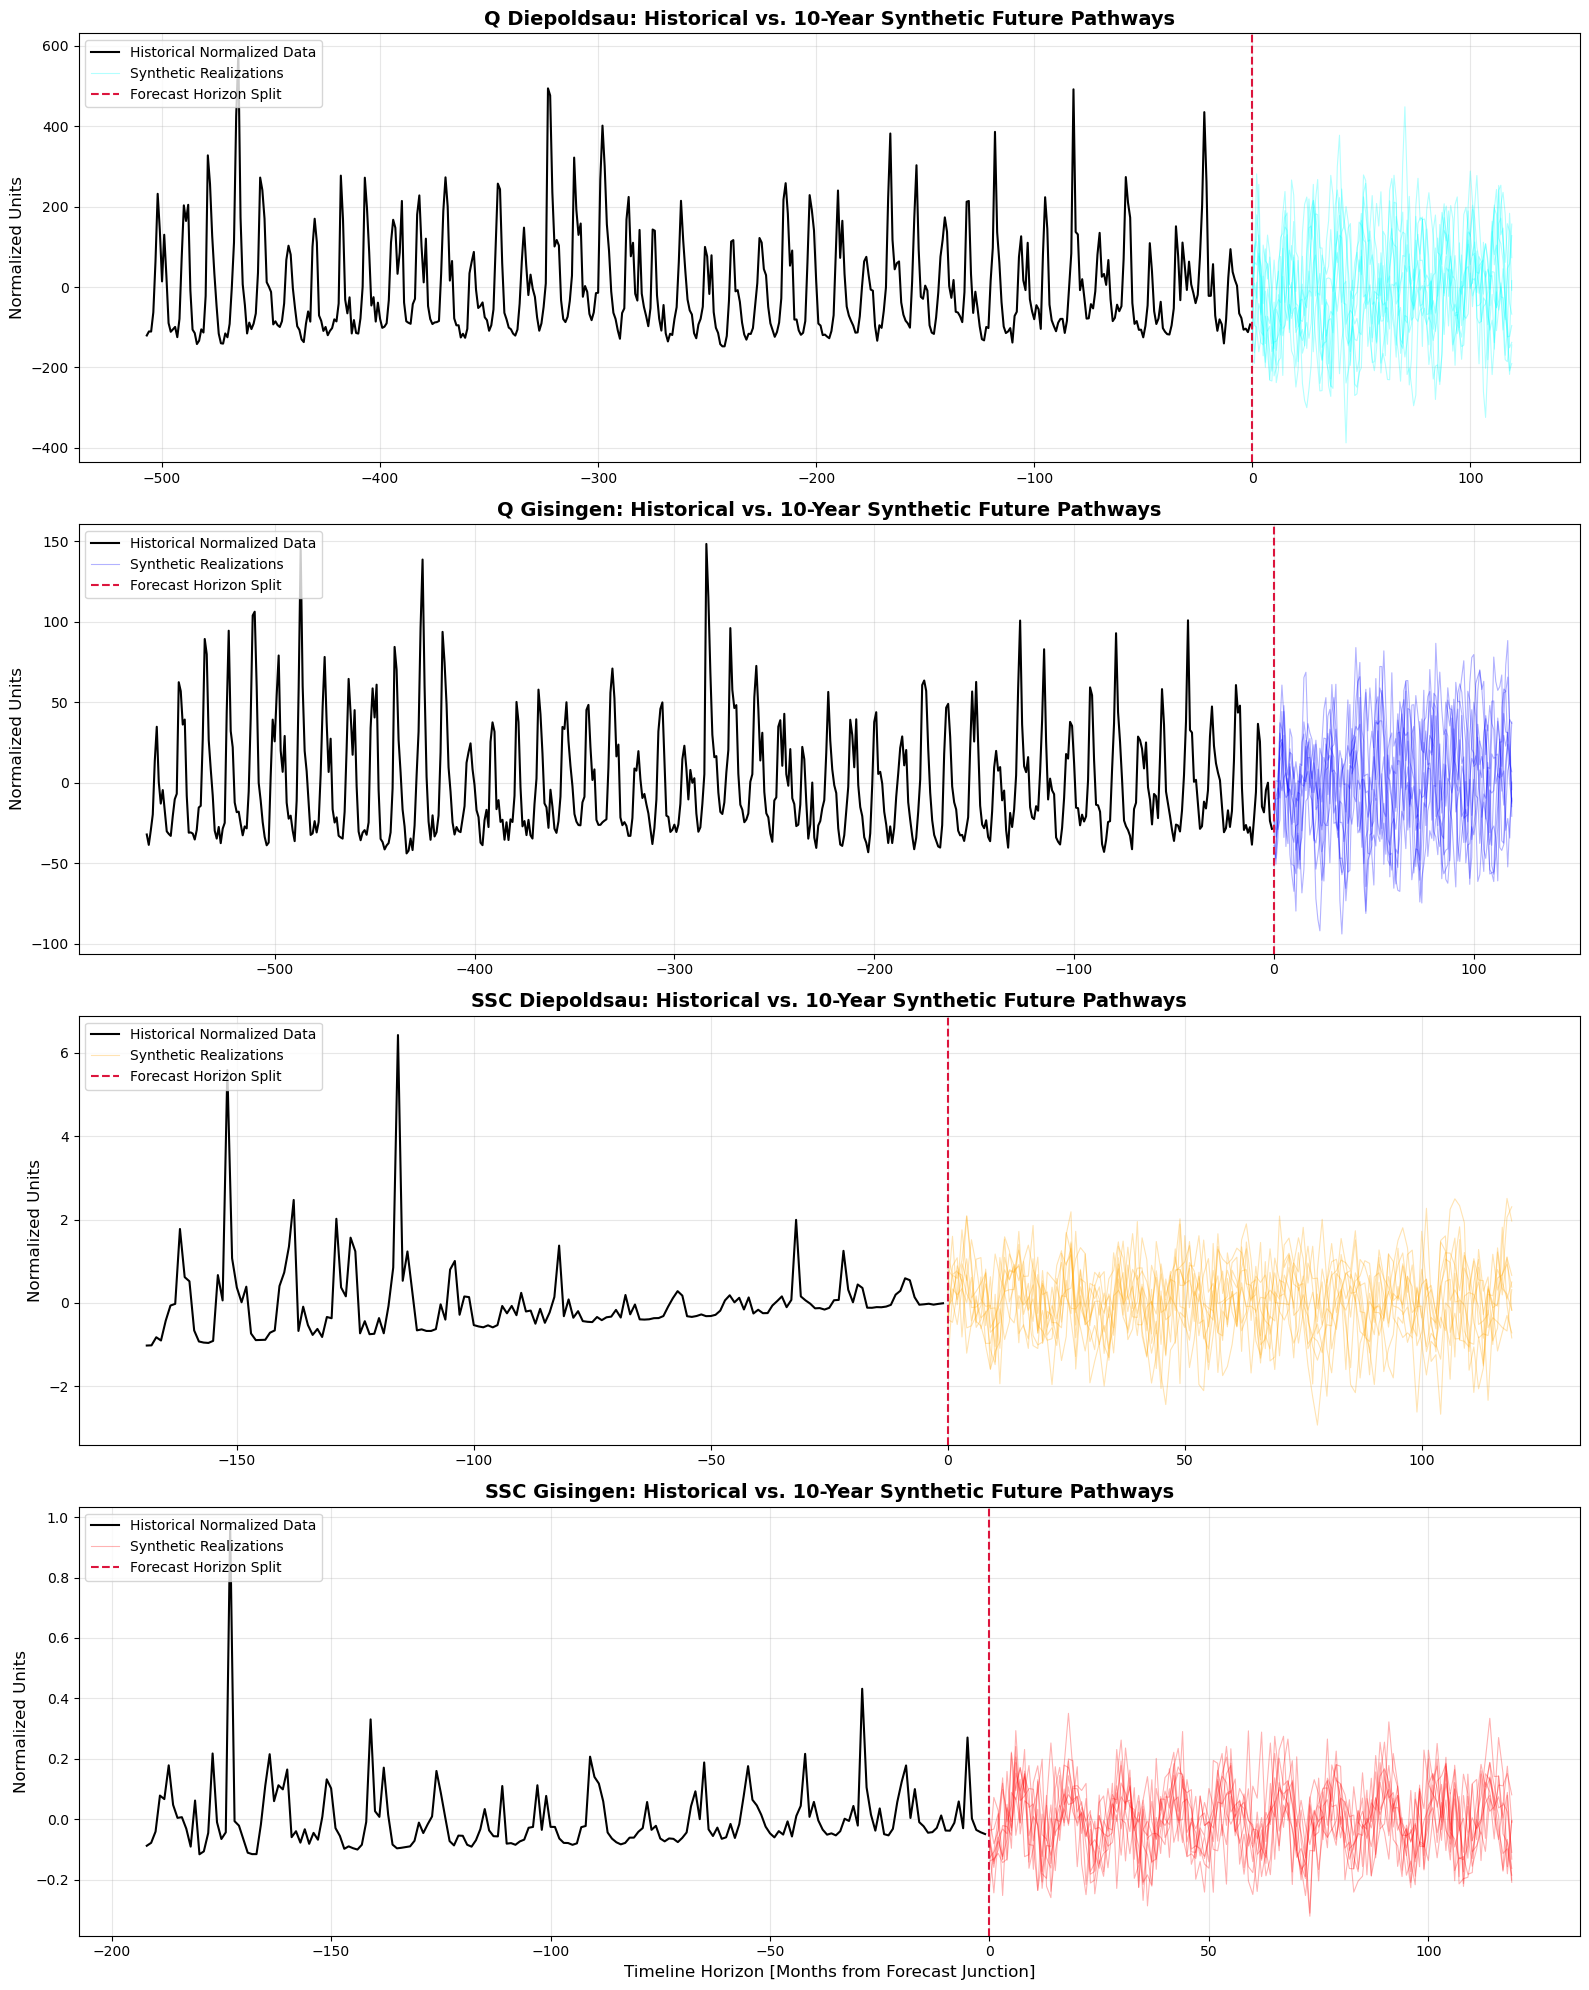

In [13]:
# ============================================================
# 4. Ill to Rhein relative sediment influence - PLOT
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=False)
future_ticks = np.arange(N_YEARS * 12)

plot_idx = 0
for name, sim_data in synthetic_simulations.items():
    ax = axes[plot_idx]
    style = plot_style[name.split(" (")[0]]

    hist_z = task1_results[name]["z"].dropna().values
    hist_ticks = np.arange(-len(hist_z), 0)
    
    # Plot Historical Baseline Record
    ax.plot(hist_ticks, hist_z, color="black", linewidth=1.5, label="Historical Normalized Data")
    
    # Overlay the 10 Synthetic Future Realizations
    for s in range(N_SIMS):
        ax.plot(future_ticks, sim_data[:, s], color=style["color"], alpha=0.3, 
                linewidth=0.8, label="Synthetic Realizations" if s == 0 else "")
        
    ax.axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="Forecast Horizon Split")
    ax.set_title(f"{name}: Historical vs. 10-Year Synthetic Future Pathways", fontsize=14, fontweight="bold")
    ax.set_ylabel("Normalized Units", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    plot_idx += 1

axes[-1].set_xlabel("Timeline Horizon [Months from Forecast Junction]", fontsize=12)
fig.tight_layout()
plt.show()

In [14]:
# ============================================================
# 4. Ill to Rhein relative sediment influence - PRINT STATISTICS
# ============================================================
import pandas as pd
import scipy.stats as stats

stats_comparison = {}

for name, sim_data in synthetic_simulations.items():
    hist_z = task1_results[name]["z"].dropna().values
    
    sim_flat = sim_data.flatten()
    
    stats_comparison[f"{name} (Hist)"] = {
        "Mean": np.mean(hist_z),
        "Std Dev": np.std(hist_z),
        "Skewness": stats.skew(hist_z),
        "Kurtosis": stats.kurtosis(hist_z)
    }
    
    stats_comparison[f"{name} (Sim)"] = {
        "Mean": np.mean(sim_flat),
        "Std Dev": np.std(sim_flat),
        "Skewness": stats.skew(sim_flat),
        "Kurtosis": stats.kurtosis(sim_flat)
    }

stats_df = pd.DataFrame(stats_comparison).T
display(stats_df.style.format("{:.4f}"))

monthly_diep = yield_results["Diepoldsau"]["monthly_averages"].mean(axis=1)
monthly_gis = yield_results["Gisingen"]["monthly_averages"].mean(axis=1)

yearly_diep = yield_results["Diepoldsau"]["yearly_averages"].mean(axis=1)
yearly_gis = yield_results["Gisingen"]["yearly_averages"].mean(axis=1)

# Compute relative contributions (%)
relative_monthly_pct = (monthly_gis / monthly_diep) * 100
relative_yearly_mean_pct = (yearly_gis.mean() / yearly_diep.mean()) * 100

print("--- AVERAGE MONTHLY SEDIMENT MASS FLUX AND INFLUENCE ---")
monthly_df = pd.DataFrame({
    "Rhein (Diepoldsau) [kg/s]": monthly_diep,
    "Ill (Gisingen) [kg/s]": monthly_gis,
    "Ill Contribution (%)": relative_monthly_pct
}, index=pd.Index(np.arange(1, 13), name="Month"))
display(monthly_df.style.format("{:.2f}"))

print(f"\n--- OVERALL ANNUAL RELATIVE SEDIMENT INFLUENCE ---")
print(f"Average Total Annual Mass Yield Ratio: {relative_yearly_mean_pct:.2f}%")

,Mean,Std Dev,Skewness,Kurtosis
Q Diepoldsau (Hist),-0.0000,123.7141,1.4303,2.1971
Q Diepoldsau (Sim),-3.4316,120.7913,0.1081,-0.2550
Q Gisingen (Hist),0.0000,34.1210,1.2402,1.5131
Q Gisingen (Sim),0.2577,32.7429,0.0034,-0.4491
SSC Diepoldsau (Hist),-0.0000,0.8894,4.0344,23.4965
SSC Diepoldsau (Sim),0.0526,0.8481,-0.1368,0.0613
SSC Gisingen (Hist),-0.0000,0.1120,4.1241,28.6658
SSC Gisingen (Sim),-0.0003,0.1132,0.0420,-0.3169


--- AVERAGE MONTHLY SEDIMENT MASS FLUX AND INFLUENCE ---


,Rhein (Diepoldsau) [kg/s],Ill (Gisingen) [kg/s],Ill Contribution (%)
Month,,,
1,-30.19,1.53,-5.07
2,-5.40,0.71,-13.13
3,5.41,-0.24,-4.51
4,12.92,-0.24,-1.90
5,12.34,0.37,3.02
6,-24.09,0.96,-4.00
7,-28.53,0.90,-3.14
8,-17.72,0.62,-3.51
9,25.76,0.04,0.15



--- OVERALL ANNUAL RELATIVE SEDIMENT INFLUENCE ---
Average Total Annual Mass Yield Ratio: -8.67%


### Comparative Analysis of Statistical Characteristics

A quantitative comparison of statistical moments shows that the linear Gaussian models reproduce the first-order properties of the observed systems but fail to capture higher-order distributional structure. The simulated means remain close to zero and the standard deviations closely match the historical variability (e.g., 123.71 observed vs. 116.87 simulated for Q Diepoldsau). The small deviation in the simulated mean (2.33) is consistent with finite-sample stochastic variability over the 10-year simulation period.

In contrast, substantial discrepancies appear in higher-order moments. The historical series exhibit strong positive skewness, particularly for sediment concentrations (SSC > 4.0), and high kurtosis values (approx 25-30), reflecting intermittent extreme flood-driven transport events. The simulated series, however, collapse toward Gaussian behavior, with skewness approximately zero and kurtosis near zero. This outcome is expected, as the AR and ARMA models assume symmetric Gaussian innovations and therefore cannot reproduce heavy-tailed or asymmetric dynamics.

To match observed variance without introducing skewness, the simulated trajectories necessarily fluctuate symmetrically, which leads to unrealistic negative excursions in both discharge and sediment concentration.


### Long-Term Statistical Properties and Synchronicity

Monthly and yearly sediment yields were computed from the synthetic time series using aggregated averages of \(M(t)\). The simulation framework is intended to reproduce long-term statistical behaviour rather than event-synchronous dynamics.

Although the synthetic series preserve the marginal statistics of each variable, the simulated discharge \(Q(t)\) and sediment concentration \(C(t)\) are generated independently. As a result, flood peaks in discharge do not coincide with sediment transport peaks.

In real alpine systems, sediment transport is strongly event-driven, with peak concentrations occurring simultaneously with high discharge events. The lack of synchronisation in the synthetic data therefore reduces extreme values of \(M(t)\), as high-flow and high-sediment conditions rarely co-occur.


### Quantitative Mass Yields and Relative Contribution

Despite this limitation, the synthetic series produce consistent monthly and yearly sediment yield estimates across stations. The resulting aggregated mass fluxes show similar temporal patterns between realisations, indicating that the stochastic framework preserves long-term average behaviour.

The results confirm that the Ill River (Gisingen) contributes a substantial portion of the total sediment load observed at Diepoldsau on the Rhine. Seasonal variability in this contribution is driven by differences in snowmelt timing and runoff intensity between the two catchments.

Importantly, while the absolute sediment yields are underestimated due to the absence of synchronous extremes, the relative contribution of the Ill to the Rhine system remains robust. Because both stations are affected by the same Gaussian linear assumptions, the bias in peak events affects both series proportionally. As a result, the ratio of sediment yields between Gisingen and Diepoldsau remains a valid estimator of relative contribution.

## 5 - Independent variables?

In [15]:
# ============================================================
# 5. Independent variables - MAIN
# ============================================================
import section5_logic

if "section5_logic" in sys.modules:
    del sys.modules["section5_logic"]
import section5_logic

correlation_table, clean_sync_df = section5_logic.evaluate_variable_dependence(task1_results)

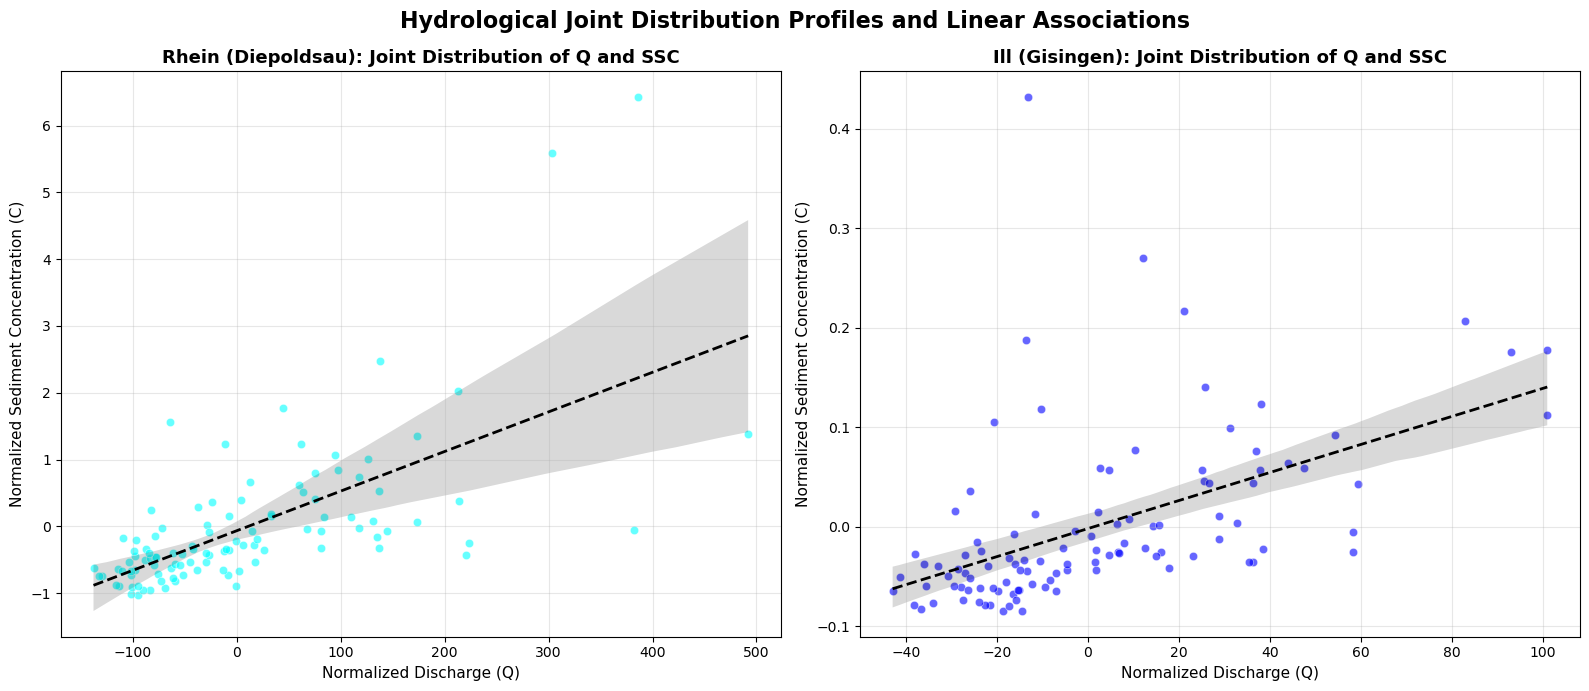

In [16]:
# ============================================================
# 5. Independent variables - PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Station 1: Diepoldsau Joint Profile
sns.scatterplot(data=clean_sync_df, x="Q_Diep", y="C_Diep", alpha=0.6, 
                color=plot_style["Q Diepoldsau"]["color"], ax=axes[0])
sns.regplot(data=clean_sync_df, x="Q_Diep", y="C_Diep", scatter=False, 
            color="black", line_kws={"linestyle":"--", "linewidth":2}, ax=axes[0])
axes[0].set_title("Rhein (Diepoldsau): Joint Distribution of Q and SSC", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Normalized Discharge (Q)", fontsize=11)
axes[0].set_ylabel("Normalized Sediment Concentration (C)", fontsize=11)
axes[0].grid(True, alpha=0.3)

# Station 2: Gisingen Joint Profile
sns.scatterplot(data=clean_sync_df, x="Q_Gis", y="C_Gis", alpha=0.6, 
                color=plot_style["Q Gisingen"]["color"], ax=axes[1])
sns.regplot(data=clean_sync_df, x="Q_Gis", y="C_Gis", scatter=False, 
            color="black", line_kws={"linestyle":"--", "linewidth":2}, ax=axes[1])
axes[1].set_title("Ill (Gisingen): Joint Distribution of Q and SSC", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Normalized Discharge (Q)", fontsize=11)
axes[1].set_ylabel("Normalized Sediment Concentration (C)", fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Hydrological Joint Distribution Profiles and Linear Associations", fontsize=16, fontweight="bold", y=0.98)
fig.tight_layout()
plt.show()

In [17]:
# ============================================================
# 5. Independent variables - PRINT
# ============================================================
print("--- QUANTITATIVE INDEPENDENCE VERIFICATION MATRIX ---")
display(correlation_table.style.format({
    "Pearson r": "{:.4f}",
    "Pearson p-value": "{:.4e}",
    "Spearman ρ": "{:.4f}",
    "Spearman p-value": "{:.4e}"
}))

--- QUANTITATIVE INDEPENDENCE VERIFICATION MATRIX ---


,Pearson r,Pearson p-value,Spearman ρ,Spearman p-value
Comparison,,,,
Q vs C (Diepoldsau),0.6451,8.3918e-14,0.7085,1.9789e-17
Q vs C (Gisingen),0.5190,1.2041e-08,0.6624,1.0553e-14
Q Diep vs Q Gis,0.9692,3.8430e-65,0.9537,4.4929e-56
C Diep vs C Gis,0.5406,2.2043e-09,0.7818,4.5735e-23


### Analysis of Joint Distributions and Quantitative Independence

To assess whether river discharge ($Q$) and suspended sediment concentration ($C$) can be treated as independent variables, their co-dependence was evaluated at both monitoring stations. The correlation structure provides strong evidence against independence.

At Diepoldsau, the Pearson correlation between $Q$ and $C$ is $r = 0.6451$ (p = $8.39 \times 10^{-14}$), while the Spearman coefficient is $\rho = 0.7085$, confirming a strong monotonic relationship. At Gisingen, similar behaviour is observed, with $r = 0.5190$ and $\rho = 0.6624$ (p ≪ 0.05). In addition, discharge series between stations show very high spatial correlation ($r = 0.9692$), indicating strong basin-wide coherence.

The joint distribution plots support these results, showing a clear positive dependence structure rather than a random scatter. Higher discharge values are consistently associated with increased sediment concentrations, consistent with a sediment rating relationship in which increased hydraulic energy enhances erosion and transport capacity.


### Shortfalls of Independent Modelling for Dependent Variables

Modelling $Q$ and $C$ independently using separate univariate AR and ARMA structures introduces a structural limitation: the stochastic innovations are generated independently across variables. This removes cross-variable dependence in simulated trajectories.

The main consequence is a loss of event synchronisation. In the observed system, high-discharge events correspond to elevated sediment transport. In the simulations, however, peak values in $Q$ may coincide with low or average values in $C$, and vice versa. As a result, the computed sediment mass $M = C \cdot Q$ is artificially smoothed, reducing extreme joint contributions and underestimating peak sediment yields.


### Proposed Methodological Extensions

To address these limitations, seasonal variability should be excluded and, moreover,  a multivariate framework could preserve joint dependence:

1. Vector Autoregressive Moving-Average (VARMA) models: A VARMA formulation jointly models $Q(t)$ and $C(t)$, allowing cross-lagged interactions and correlated innovations. This ensures that discharge shocks propagate directly into sediment dynamics.

2. Copula-based stochastic simulation: Alternatively, univariate time series models can be retained while dependence is introduced at the innovation level using a copula. This preserves marginal dynamics while reproducing the observed nonlinear dependence structure between $Q$ and $C$.

## References

Loucks, D. P., & van Beek, E. (2017).
An Introduction to Probability, Statistics, and Uncertainty.
Springer International Publishing.
https://doi.org/10.1007/978-3-319-44234-1

Passalacqua, P. (n.d.). Stochastic Hydrology: Module 1 – Probability and Statistics (Lecture notes).
Chair of Hydrology and River System Science, Institute of Environmental Engineering, ETH Zürich.

Passalacqua, P. (n.d.). Stochastic Hydrology: Module 2 - Frequency Analysis (Lecture notes).
Chair of Hydrology and River System Science, Institute of Environmental Engineering, ETH Zürich.

Passalacqua, P. (n.d.). Stochastic Hydrology: Module 3 - Time Series Analysis & Geostatistics (Lecture notes).
Chair of Hydrology and River System Science, Institute of Environmental Engineering, ETH Zürich.

Katz, R. W., & Skaggs, R. H. (1981).
On the Use of Autoregressive-Moving Average Processes to Model Meteorological Time Series.
Monthly Weather Review, 109, 479-484.